In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

In [ ]:

# Wielki syf, do kalibracji i obliczeń

gold_data = pd.read_csv('londonfixes-current-clean_1990_.csv')
gold_df = gold_data[["Date", "Gold PM Fix"]].copy()

usdpln_df = pd.read_csv("usdpln_d.csv", usecols=["Data", "Zamkniecie"])

usdpln_df.rename(columns={"Data": "Date", "Zamkniecie": "USDPLN"}, inplace=True)
gold_df.rename(columns={"Gold PM Fix": "Gold"}, inplace=True)

usdpln_df['Date'] = pd.to_datetime(usdpln_df['Date'])
gold_df['Date'] = pd.to_datetime(gold_df['Date'])

df = pd.merge(gold_df, usdpln_df, on="Date", how="inner")
df['Gold'] = pd.to_numeric(df['Gold'], errors='coerce')
df = df[df['Gold'] > 0]
df.sort_values(by="Date", inplace=True)
df.set_index("Date", inplace=True)
df.dropna(inplace=True)

df = df.loc['2014-06-29':'2024-06-29']

df['Gold_PLN'] = df['Gold'] * df['USDPLN']

returns = df.pct_change().dropna()
log_returns = np.log(df / df.shift(1)).dropna()

num_of_days = 252

end_date = pd.to_datetime('2024-06-30')
periods = {
    '1Y': end_date - pd.DateOffset(years=1),
    # '2Y': end_date - pd.DateOffset(years=2),
    # '3Y': end_date - pd.DateOffset(years=3),
    # '5Y': end_date - pd.DateOffset(years=5),
    # '7Y': end_date - pd.DateOffset(years=7),
    # '10Y': end_date - pd.DateOffset(years=10),
}

for label, start_date in periods.items():
    period_log_returns = log_returns.loc[start_date:end_date]
    
    volatility = period_log_returns.std() * np.sqrt(num_of_days)
    drift = period_log_returns.mean() * num_of_days
    correlation = period_log_returns.corr()



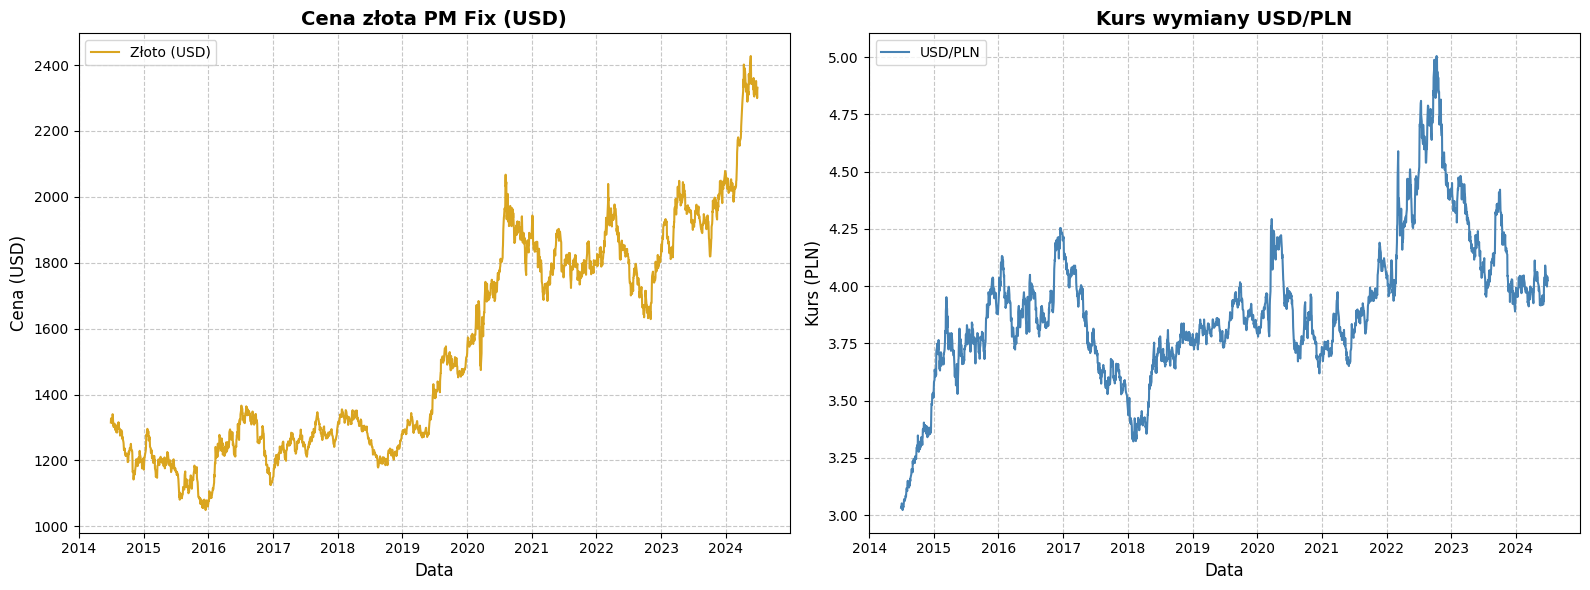

In [3]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

ax1.plot(df.index, df['Gold'], color='goldenrod', label='Złoto (USD)')
ax1.set_title('Cena złota PM Fix (USD)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Cena (USD)', fontsize=12)
ax1.set_xlabel('Data', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='upper left')

ax2.plot(df.index, df['USDPLN'], color='steelblue', label='USD/PLN')
ax2.set_title('Kurs wymiany USD/PLN', fontsize=14, fontweight='bold')
ax2.set_ylabel('Kurs (PLN)', fontsize=12)
ax2.set_xlabel('Data', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:

# Wielki syf: funkcje

def simulate_correlated_paths(S1_0, S2_0, mu1, mu2, sigma1, sigma2, rho, dt, T, n_paths):
    n_steps = int(round(T / dt))
    time = np.linspace(0, T, n_steps + 1)

    Z1 = np.random.standard_normal((n_steps, n_paths))
    Z2 = np.random.standard_normal((n_steps, n_paths))
    
    Z2_corr = rho * Z1 + np.sqrt(1.0 - rho**2) * Z2
    
    W1 = np.vstack([np.zeros((1, n_paths)), np.cumsum(Z1 * np.sqrt(dt), axis=0)])
    W2 = np.vstack([np.zeros((1, n_paths)), np.cumsum(Z2_corr * np.sqrt(dt), axis=0)])

    time_2d = time.reshape(-1, 1)

    S1 = S1_0 * np.exp((mu1 - 0.5 * sigma1**2) * time_2d + sigma1 * W1)
    S2 = S2_0 * np.exp((mu2 - 0.5 * sigma2**2) * time_2d + sigma2 * W2)
    
    return time, S1, S2

def d1_d2(S, S0, K, tau, r_usd, rho, sigma_S, sigma_X):
    if tau <= 1e-12:
        return 0.0, 0.0
        
    d1 = (np.log(S / (K * S0)) + (r_usd - rho * sigma_X * sigma_S + 0.5 * sigma_S**2) * tau) / (sigma_S * np.sqrt(tau))
    d2 = d1 - sigma_S * np.sqrt(tau)
    return d1, d2

def quanto(S, S0, K, tau, r_pln, r_usd, rho, sigma_S, sigma_X):
    if tau <= 1e-12:
        return 100 * np.maximum(S/S0 - K, 0) 
        
    d1, d2 = d1_d2(S, S0, K, tau, r_usd, rho, sigma_S, sigma_X)
    
    q = r_pln - r_usd + rho * sigma_X * sigma_S
    
    price = (100 / S0) * (S * np.exp(-q * tau) * norm.cdf(d1) - K * S0 * np.exp(-r_pln * tau) * norm.cdf(d2))
    return price

def delta_hedging_step(S, X, delta_S_old, delta_X_old, cash_PLN,
                       S0, K, tau, r_pln, r_usd, rho, sigma_S, sigma_X, dt):
    
    cash_PLN = cash_PLN * np.exp(r_pln * dt)    # odsetki od gotówki
    delta_X_old = delta_X_old * np.exp(r_usd * dt)  # odsetki od gotówki w USD

    Pi = delta_S_old * S * X + delta_X_old * X + cash_PLN   # Wartość portfela przed rebalansowaniem

    d1, _ = d1_d2(S, S0, K, tau, r_usd, rho, sigma_S, sigma_X)
    q = r_pln - r_usd + rho * sigma_X * sigma_S # Magiczne q od Ewy
    dV_dS = (100 / S0) * np.exp(-q * tau) * norm.cdf(d1)    # Pochodna ze wzoru

    # Nowe delty
    delta_S_new = (1 / X) * dV_dS
    delta_X_new = -(S / X) * dV_dS

    # Aktualizacja gotówki w PLN 
    cash_PLN = cash_PLN - (delta_S_new - delta_S_old) * S * X - (delta_X_new - delta_X_old) * X
    
    return delta_S_new, delta_X_new, cash_PLN, Pi

def simulate_delta_hedging(time, S, X, S0, K, T, r_pln, r_usd, rho, sigma_S, sigma_X, dt):
    n_steps = len(time) - 1

    # Śledzimy skład portfela
    delta_S = np.zeros_like(S)
    delta_X = np.zeros_like(X)
    cash_PLN = np.zeros_like(S)

    Pi = np.zeros_like(S) # Śledzimy wartość portfela

    # Wartość opcji w dniu 0
    V0 = quanto(S[0], S0, K, T, r_pln, r_usd, rho, sigma_S, sigma_X)
    
    # Pierwszy hedging
    delta_S[0], delta_X[0], cash_PLN[0], Pi[0] = delta_hedging_step(
        S[0], X[0], 0, 0, V0, 
        S0, K, T, r_pln, r_usd, rho, sigma_S, sigma_X, 0
    )

    # Symulacja życia opcji
    for i in range(1, n_steps):
        tau = T - time[i]
        
        delta_S[i], delta_X[i], cash_PLN[i], Pi[i] = delta_hedging_step(
            S[i], X[i], delta_S[i-1], delta_X[i-1], cash_PLN[i-1],
            S0, K, tau, r_pln, r_usd, rho, sigma_S, sigma_X, dt
        )

    # Ostatni dzień (bez rebalansowania)
    delta_S[-1] = delta_S[-2]
    delta_X[-1] = delta_X[-2] * np.exp(r_usd * dt)
    cash_PLN[-1] = cash_PLN[-2] * np.exp(r_pln * dt)
    
    # Wartość portfela na koniec
    Pi[-1] = delta_S[-1] * S[-1] * X[-1] + delta_X[-1] * X[-1] + cash_PLN[-1]
    
    payoff = 100 * np.maximum(S[-1]/S0 - K, 0)
    hedging_error = Pi[-1] - payoff # Być może trzeba spieniężyć portfel, do przedyskutowania

    return time, S, X, Pi, payoff, hedging_error, delta_S, delta_X, cash_PLN

def quanto_2(Y, X, S0, K, tau, r_pln, r_usd, rho_yx, sigma_y, sigma_x):
    
    if tau <= 1e-12:
        return 100 * np.maximum((Y/X)/S0 - K, 0)
        
    q = r_pln - r_usd - sigma_x ** 2 + rho_yx * sigma_y * sigma_x
    sigma_z = np.sqrt(sigma_y ** 2 + sigma_x ** 2 - 2 * rho_yx * sigma_y * sigma_x)
    r_hat = r_pln - q
    
    spot_ratio = (Y / X) / S0
    
    d1 = (np.log(spot_ratio / K) + (r_hat + 0.5 * sigma_z ** 2) * tau) / (sigma_z * np.sqrt(tau))
    d2 = d1 - sigma_z * np.sqrt(tau)
    
    cena = 100 * (spot_ratio * np.exp(-q * tau) * norm.cdf(d1) - K * np.exp(-r_pln * tau) * norm.cdf(d2))
    return cena

def delta_hedging_step_2(Y, X, delta_Y_old, delta_X_old, cash_PLN,
                         S0, K, tau, r_pln, r_usd, rho, sigma_Y, sigma_X, dt):
    
    cash_PLN = cash_PLN * np.exp(r_pln * dt)    # odsetki od gotówki
    delta_X_old = delta_X_old * np.exp(r_usd * dt)  # odsetki od gotówki w USD

    Pi = delta_Y_old * Y + delta_X_old * X + cash_PLN   # Wartość portfela przed rebalansowaniem

    q = r_pln - r_usd - sigma_X ** 2 + rho * sigma_Y * sigma_X # Magiczne q od Ewy
    sigma_z = np.sqrt(sigma_Y ** 2 + sigma_X ** 2 - 2 * rho * sigma_Y * sigma_X)
    r_hat = r_pln - q
    
    if tau <= 1e-12:
        dV_dY = 0
    else:
        d1 = (np.log(Y / (X * S0 * K)) + (r_hat + 0.5 * sigma_z ** 2) * tau) / (sigma_z * np.sqrt(tau))
        dV_dY = (100 / (X * S0)) * np.exp(-q * tau) * norm.cdf(d1)    # Pochodna ze wzoru

    # Nowe delty
    delta_Y_new = dV_dY
    delta_X_new = -(Y / X) * dV_dY

    # Aktualizacja gotówki w PLN 
    cash_PLN = cash_PLN - (delta_Y_new - delta_Y_old) * Y - (delta_X_new - delta_X_old) * X
    
    return delta_Y_new, delta_X_new, cash_PLN, Pi

def simulate_delta_hedging_2(time, Y, X, S0, K, T, r_pln, r_usd, rho, sigma_Y, sigma_X, dt):
    n_steps = len(time) - 1

    # Śledzimy skład portfela
    delta_Y = np.zeros_like(Y)
    delta_X = np.zeros_like(X)
    cash_PLN = np.zeros_like(Y)

    Pi = np.zeros_like(Y) # Śledzimy wartość portfela

    # Wartość opcji w dniu 0
    V0 = quanto_2(Y[0], X[0], S0, K, T, r_pln, r_usd, rho, sigma_Y, sigma_X)
    
    # Pierwszy hedging
    delta_Y[0], delta_X[0], cash_PLN[0], Pi[0] = delta_hedging_step_2(
        Y[0], X[0], 0, 0, V0, 
        S0, K, T, r_pln, r_usd, rho, sigma_Y, sigma_X, 0
    )

    # Symulacja życia opcji
    for i in range(1, n_steps):
        tau = T - time[i]
        
        delta_Y[i], delta_X[i], cash_PLN[i], Pi[i] = delta_hedging_step_2(
            Y[i], X[i], delta_Y[i-1], delta_X[i-1], cash_PLN[i-1],
            S0, K, tau, r_pln, r_usd, rho, sigma_Y, sigma_X, dt
        )

    # Ostatni dzień (bez rebalansowania)
    delta_Y[-1] = delta_Y[-2]
    delta_X[-1] = delta_X[-2] * np.exp(r_usd * dt)
    cash_PLN[-1] = cash_PLN[-2] * np.exp(r_pln * dt)
    
    # Wartość portfela na koniec
    Pi[-1] = delta_Y[-1] * Y[-1] + delta_X[-1] * X[-1] + cash_PLN[-1]
    
    payoff = 100 * np.maximum((Y[-1] / X[-1]) / S0 - K, 0)
    hedging_error = Pi[-1] - payoff # Być może trzeba spieniężyć portfel, do przedyskutowania

    return time, Y, X, Pi, payoff, hedging_error, delta_Y, delta_X, cash_PLN

def price1_caly_okres_nowe(S_t, S0, K, r_pln, r_usd, rho, sigma_x, sigma_s, t: np.ndarray, T=1, C=100):
    q = r_pln - r_usd + rho * sigma_s * sigma_x
    r_hat = r_pln - q
    tau = T - t
    d1 = (np.log(S_t / (S0 * K)) + (r_hat + 0.5 * sigma_s ** 2) * tau) / (sigma_s * np.sqrt(tau))
    d2 = d1 - sigma_s * np.sqrt(tau)

    cena = (C/S0) * (S_t * np.exp((-q) * (tau)) * norm.cdf(d1) - K * S0 * np.exp(-r_pln * (tau)) * norm.cdf(d2))
    return cena

def price2_caly_okres_nowe(S_t, S0, K, r_pln, r_usd, sigma_y, sigma_x, rho, t: np.ndarray, T=1, C=100):
    q = r_pln - r_usd - sigma_x ** 2 + rho * sigma_y * sigma_x
    sigma_z = np.sqrt(sigma_y ** 2 + sigma_x ** 2 - 2 * rho * sigma_y * sigma_x)
    r_hat = r_pln - q
    tau = T - t

    d1 = (np.log(S_t / (S0 * K)) + (r_hat + 0.5 * sigma_z ** 2) * (tau)) / (sigma_z * np.sqrt(tau))
    d2 = d1 - sigma_z * np.sqrt(tau)

    cena = (C/S0) * (S_t * np.exp((-q) * (tau)) * norm.cdf(d1) - K * S0 * np.exp(-r_pln * (tau)) * norm.cdf(d2))
    return cena






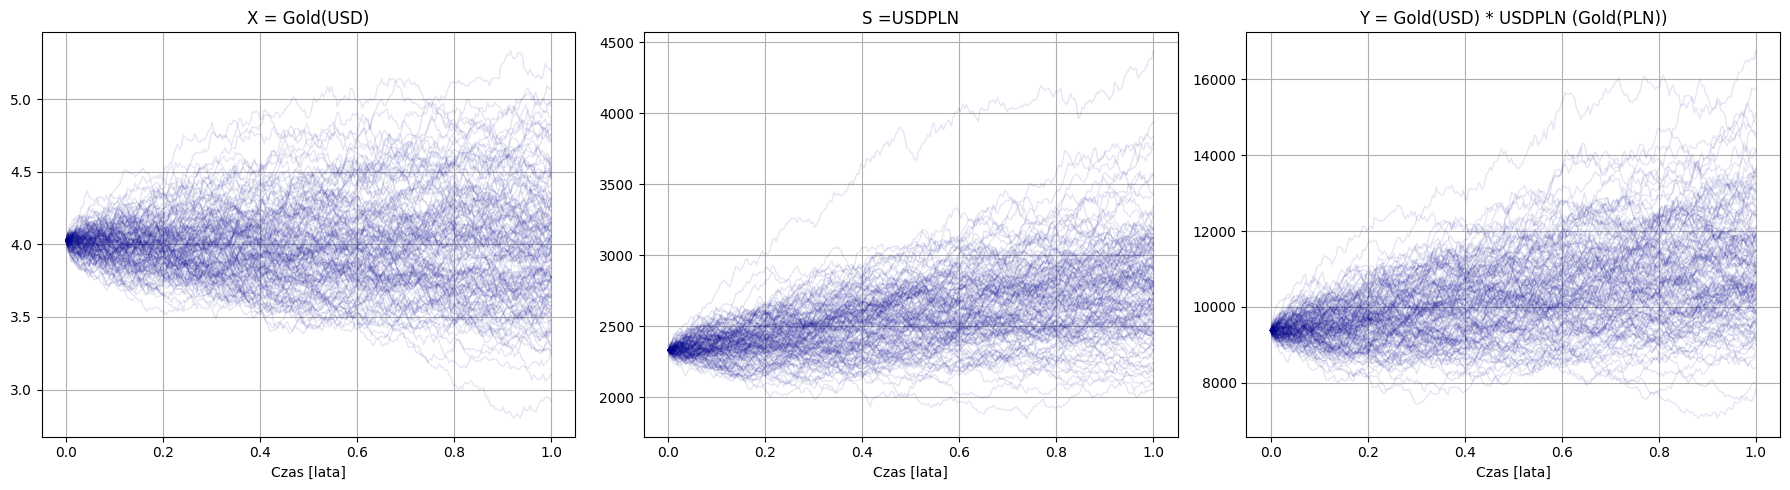

In [5]:
set_seed = 42

T = 1.0
N = 252
dt = T / N
n_paths = 1000
S0_gold = df['Gold'].iloc[-1]
S0_usdpln = df['USDPLN'].iloc[-1]
K = 1.0
# S0_gold_pln = df['Gold_PLN'].iloc[-1]

mu1 = drift['Gold']
mu2 = drift['USDPLN']
sigma1 = volatility['Gold']
sigma2 = volatility['USDPLN']
rho = correlation.loc['Gold', 'USDPLN']
r_pln = 0.05
r_usd = 0.02
# rho_SX = correlation.loc['Gold', 'USDPLN']
# rho_XY = correlation.loc['USDPLN', 'Gold_PLN']

t, X, S = simulate_correlated_paths(S0_gold, S0_usdpln, mu1, mu2, sigma1, sigma2, rho, dt, T, n_paths)

Y = X * S

n_plot = 150

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

col = 'darkblue'
alpha = 0.1

axes[0].plot(t, S[:, :n_plot], lw=1, color=col, alpha=alpha)
axes[0].set_title('X = Gold(USD)')

axes[1].plot(t, X[:, :n_plot], lw=1, color=col, alpha=alpha)
axes[1].set_title('S =USDPLN')

axes[2].plot(t, Y[:, :n_plot], lw=1, color=col, alpha=alpha)
axes[2].set_title('Y = Gold(USD) * USDPLN (Gold(PLN))')

for ax in axes:
    ax.set_xlabel('Czas [lata]')
    ax.grid(True)

plt.tight_layout()
plt.show()

## Delta hedging - model 1

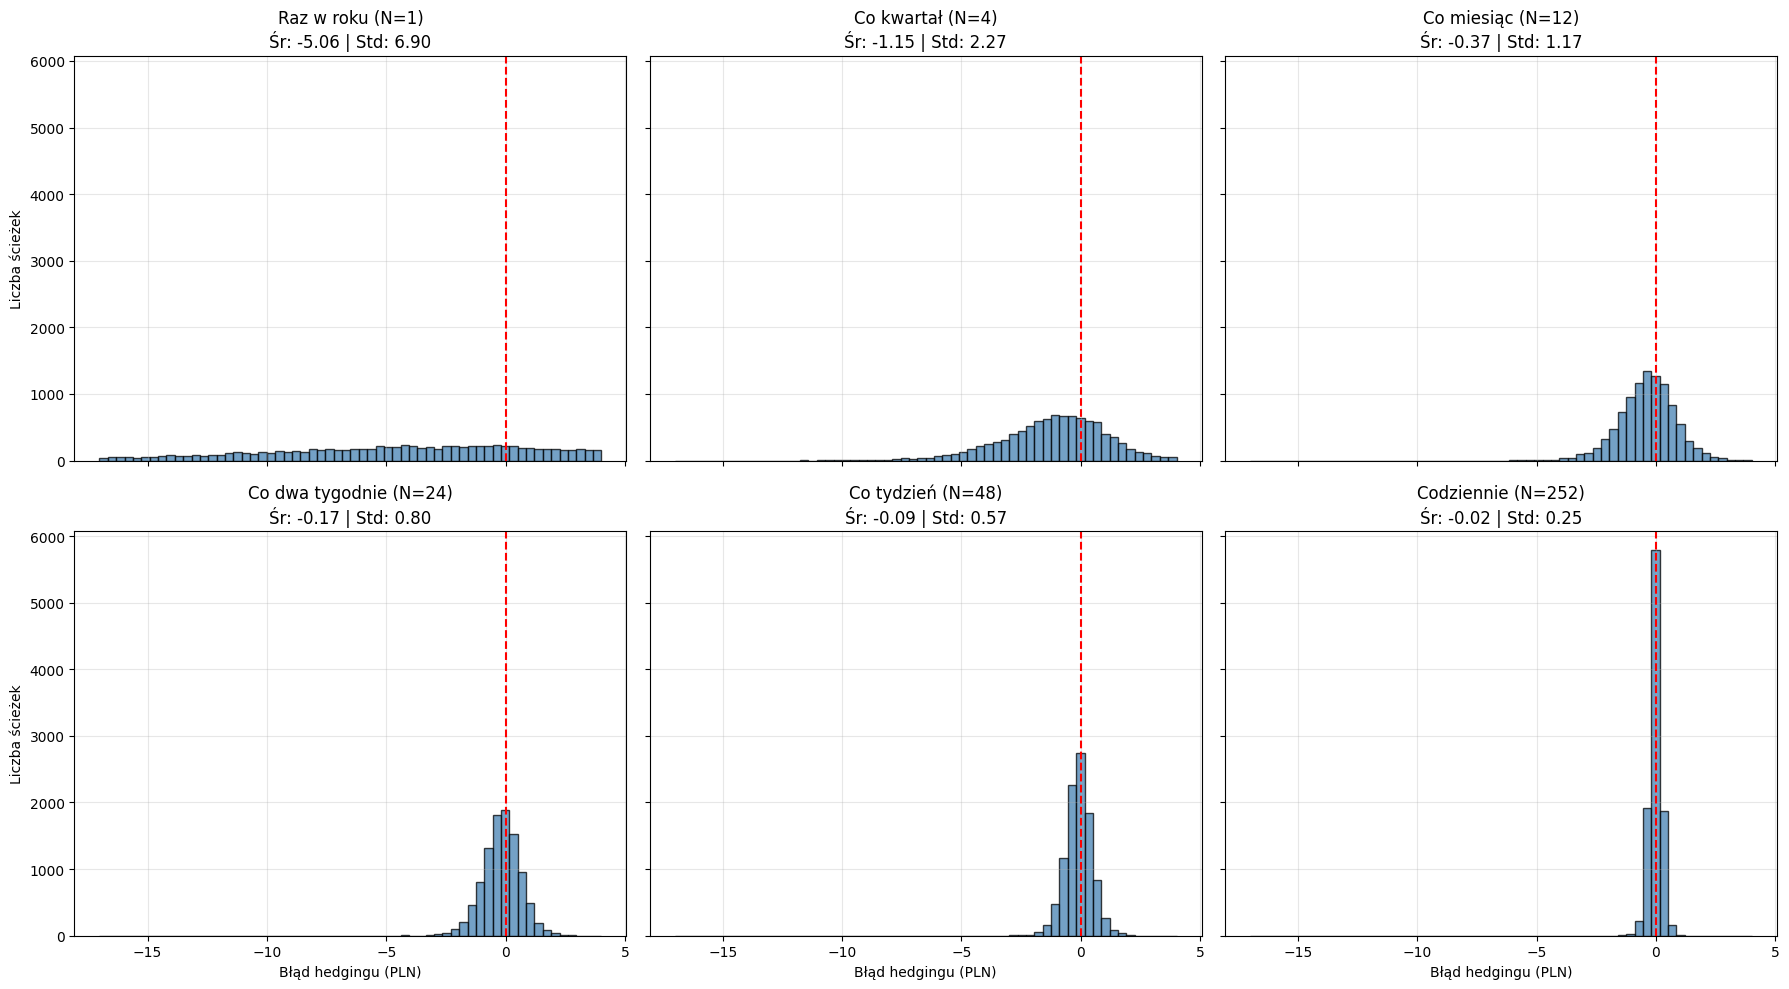

In [6]:
n_paths = 10000

N_list = [1, 4, 12, 24, 48, 252]
nazwy = ['Raz w roku', 'Co kwartał', 'Co miesiąc',
         'Co dwa tygodnie', 'Co tydzień', 'Codziennie']

wszystkie_bledy = []

for N in N_list:
    dt = T / N
    
    time_grid, paths_S, paths_X = simulate_correlated_paths(
        S0_gold, S0_usdpln, mu1, mu2, sigma1, sigma2, rho, dt, T, n_paths
    )
    
    _, _, _, _, _, err, _, _, _ = simulate_delta_hedging(
        time_grid, paths_S, paths_X,
        S0_gold, K, T, r_pln, r_usd, rho, sigma1, sigma2, dt
    )
    
    wszystkie_bledy.append(np.asarray(err).flatten())


# === WSPÓLNY ZAKRES OSI X ===
xmin = min(b.min() for b in wszystkie_bledy)
xmax = max(b.max() for b in wszystkie_bledy)

all_errors = np.concatenate(wszystkie_bledy)

xmin = np.percentile(all_errors, 1)
xmax = np.percentile(all_errors, 99)

# ===== RYSOWANIE =====
fig, axes = plt.subplots(2, 3, figsize=(18, 10),
                         sharex=True, sharey=True)

axes = axes.flatten()

for i in range(6):
    bledy = wszystkie_bledy[i]
    
    axes[i].hist(
        bledy,
        bins=60,
        range=(xmin, xmax),     # ✅ przycięta oś
        color='steelblue',
        edgecolor='black',
        alpha=0.75
    )
    
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1.5)
    
    axes[i].set_title(
        f'{nazwy[i]} (N={N_list[i]})\n'
        f'Śr: {np.mean(bledy):.2f} | Std: {np.std(bledy):.2f}'
    )
    
    axes[i].grid(True, alpha=0.3)

axes[0].set_ylabel('Liczba ścieżek')
axes[3].set_ylabel('Liczba ścieżek')

for ax in axes[3:]:
    ax.set_xlabel('Błąd hedgingu (PLN)')

plt.tight_layout()
plt.show()

## Delta hedging - model 2 (Y = SX)

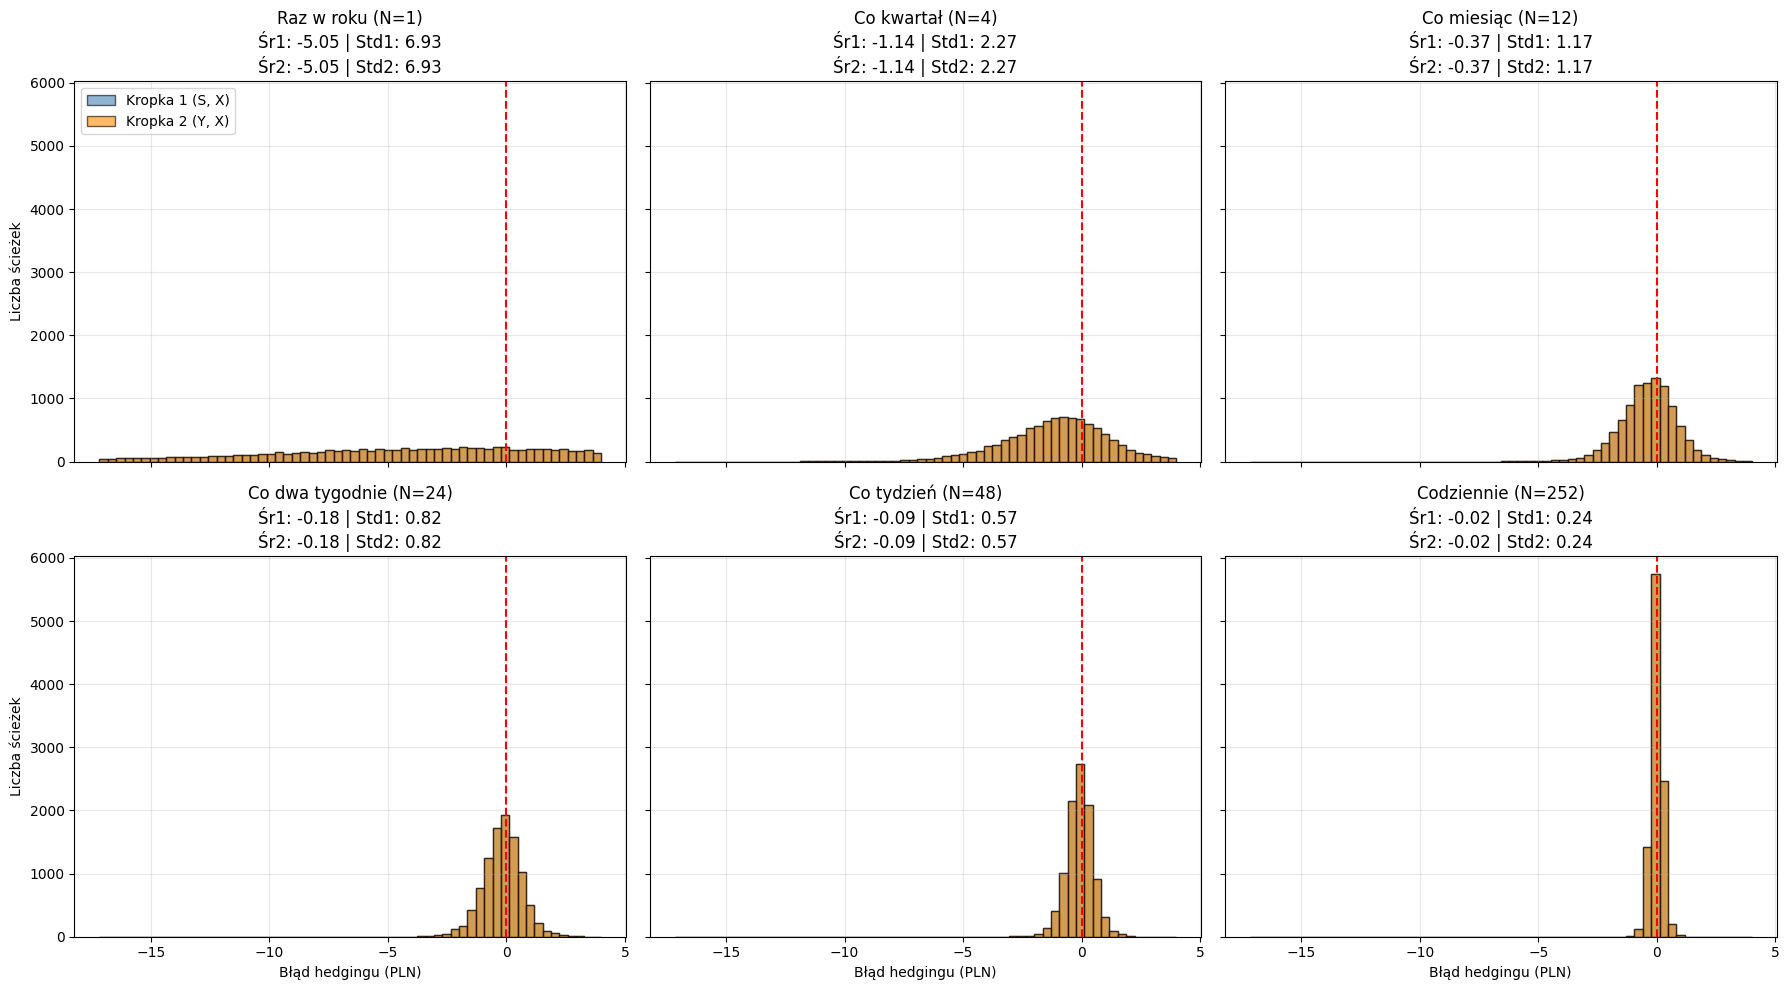

In [7]:
set_seed = 42
T = 1.0
n_paths = 10000
K = 1.0

S0_gold = df['Gold'].iloc[-1]
S0_usdpln = df['USDPLN'].iloc[-1]
# Y0 = S0_gold * S0_usdpln

mu1 = drift['Gold']
mu2 = drift['USDPLN']
sigma1 = volatility['Gold']        #  sigma_S
sigma2 = volatility['USDPLN']      #  sigma_X
rho_SX = correlation.loc['Gold', 'USDPLN']

r_pln = 0.05
r_usd = 0.02

# Parametry dla złota w PLN 
sigma_Y = volatility['Gold_PLN'] 
rho_YX = correlation.loc['USDPLN', 'Gold_PLN']

N_list = [1, 4, 12, 24, 48, 252]
nazwy = ['Raz w roku', 'Co kwartał', 'Co miesiąc', 'Co dwa tygodnie', 'Co tydzień', 'Codziennie']

wszystkie_bledy_1 = []
wszystkie_bledy_2 = []

np.random.seed(set_seed)

for N in N_list:
    dt = T / N

    time_grid, paths_S, paths_X = simulate_correlated_paths(
        S0_gold, S0_usdpln, mu1, mu2, sigma1, sigma2, rho_SX, dt, T, n_paths
    )
    
    paths_Y = paths_S * paths_X

# Kropka 1
    _, _, _, _, _, err_1, delta_S, delta_X1, cash_1 = simulate_delta_hedging(
        time_grid, paths_S, paths_X, S0_gold, K, T, r_pln, r_usd, rho_SX, sigma1, sigma2, dt
    )
    wszystkie_bledy_1.append(np.asarray(err_1).flatten())

# Kropka 2
    _, _, _, _, _, err_2, delta_Y, delta_X2, cash_2 = simulate_delta_hedging_2(
        time_grid, paths_Y, paths_X, S0_gold, K, T, r_pln, r_usd, rho_YX, sigma_Y, sigma2, dt
    )
    wszystkie_bledy_2.append(np.asarray(err_2).flatten())


all_errors = np.concatenate(wszystkie_bledy_1 + wszystkie_bledy_2)
xmin = np.percentile(all_errors, 1)
xmax = np.percentile(all_errors, 99)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(6):
    bledy_1 = wszystkie_bledy_1[i]
    bledy_2 = wszystkie_bledy_2[i]
    
    axes[i].hist(bledy_1, bins=60, range=(xmin, xmax), 
                 color='steelblue', edgecolor='black', alpha=0.6, label='Kropka 1 (S, X)')
                 
    axes[i].hist(bledy_2, bins=60, range=(xmin, xmax), 
                 color='darkorange', edgecolor='black', alpha=0.6, label='Kropka 2 (Y, X)')
    
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1.5)
    
    axes[i].set_title(
        f'{nazwy[i]} (N={N_list[i]})\n'
        f'Śr1: {np.mean(bledy_1):.2f} | Std1: {np.std(bledy_1):.2f}\n'
        f'Śr2: {np.mean(bledy_2):.2f} | Std2: {np.std(bledy_2):.2f}'
    )
    
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].legend()

axes[0].set_ylabel('Liczba ścieżek')
axes[3].set_ylabel('Liczba ścieżek')

for ax in axes[3:]:
    ax.set_xlabel('Błąd hedgingu (PLN)')

plt.tight_layout()
plt.show()

## Delta hedging - model 2 vs model 1 (niezależne generowanie)

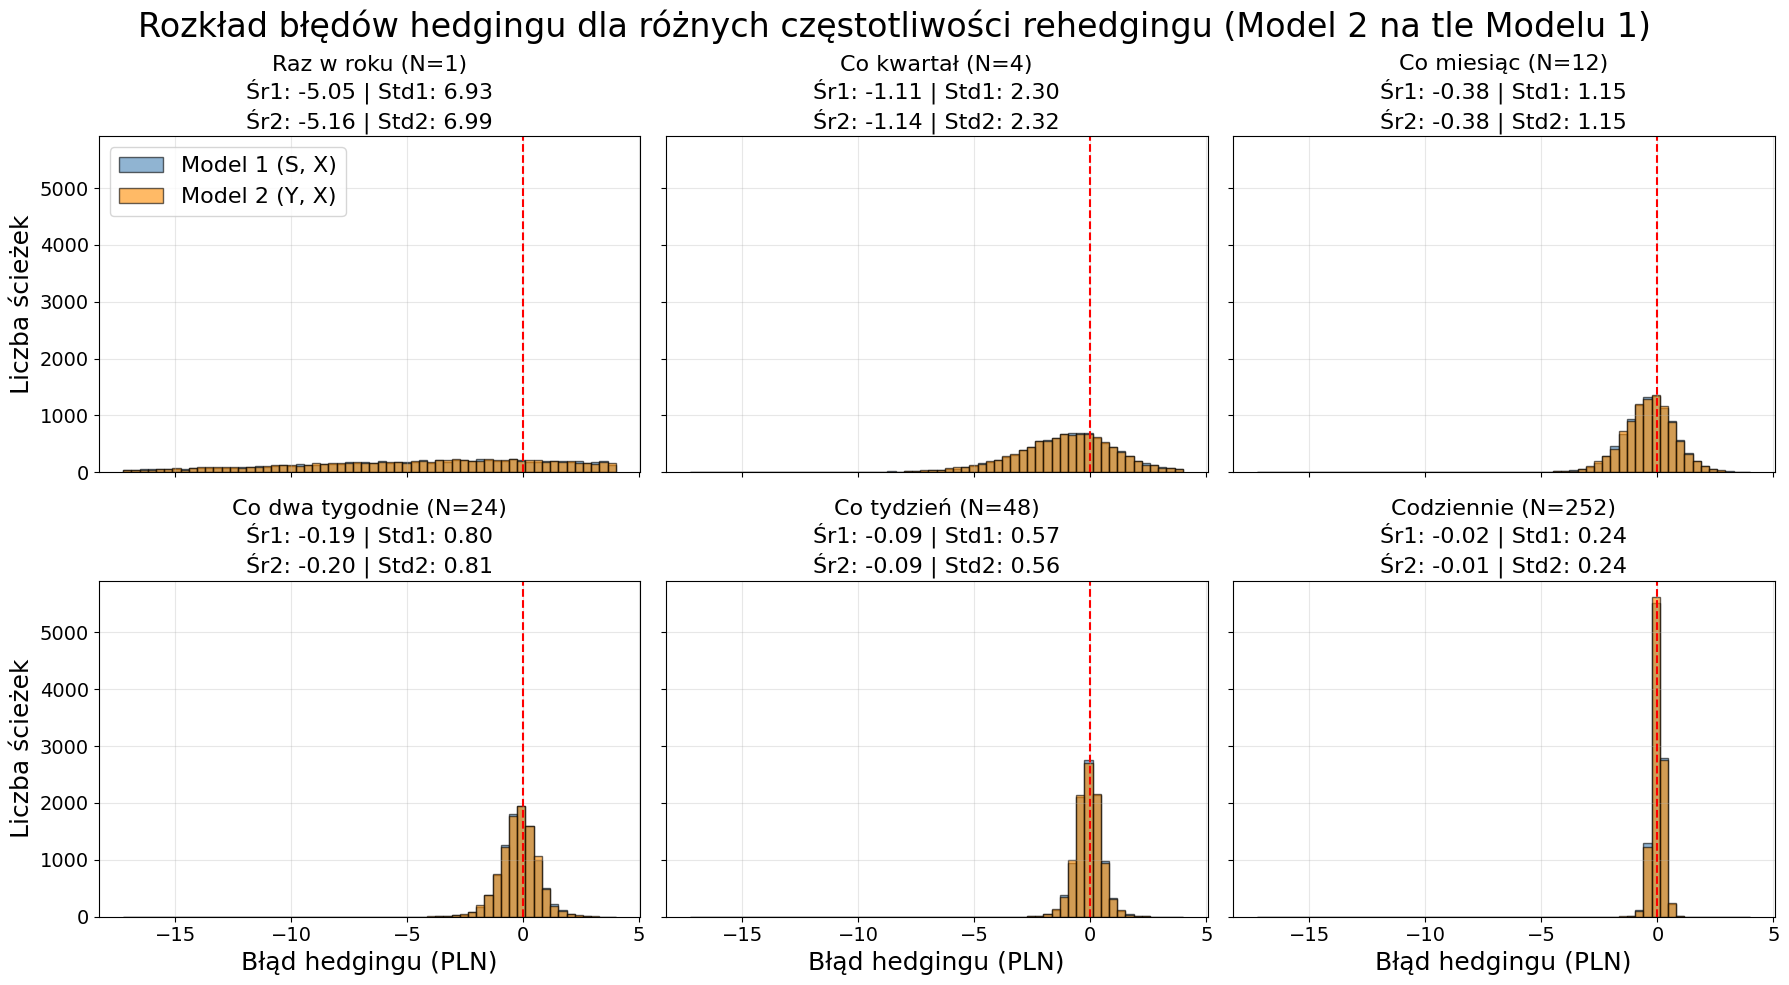

In [8]:
# ==========================================
# GENEROWANIE DANYCH DLA RÓŻNYCH CZĘSTOTLIWOŚCI
# ==========================================

wszystkie_bledy_1_diff = []
wszystkie_bledy_2_diff = []

N_list = [1, 4, 12, 24, 48, 252]
nazwy = ['Raz w roku', 'Co kwartał', 'Co miesiąc', 'Co dwa tygodnie', 'Co tydzień', 'Codziennie']

np.random.seed(42)

for N in N_list:
    dt = T / N
    time_grid = np.linspace(0, T, N + 1)
    
    # --- KROPKA 1: Generujemy S i X ---
    np.random.seed(42)
    _, paths_S, paths_X_1 = simulate_correlated_paths(
        S0_gold, S0_usdpln, mu1, mu2, sigma1, sigma2, rho_SX, dt, T, n_paths
    )
    
    # --- KROPKA 2: Generujemy Y i X NIEZALEŻNIE (empiryczne parametry) ---
    mu_Y = drift['Gold_PLN']
    sigma_Y_empiryczne = volatility['Gold_PLN']
    rho_YX_empiryczne = correlation.loc['USDPLN', 'Gold_PLN']
    Y0 = S0_gold * S0_usdpln
    
    np.random.seed(42)
    _, paths_Y, paths_X_2 = simulate_correlated_paths(
        Y0, S0_usdpln, mu_Y, mu2, sigma_Y, sigma2, rho_YX, dt, T, n_paths
    )
    
    # --- HEDGING 1 ---
    _, _, _, _, _, err_1_diff, delta_S, delta_X1, cash_1 = simulate_delta_hedging(
        time_grid, paths_S, paths_X_1, S0_gold, K, T, r_pln, r_usd, rho_SX, sigma1, sigma2, dt
    )
    wszystkie_bledy_1_diff.append(np.asarray(err_1_diff).flatten())
    
    # --- HEDGING 2 ---
    _, _, _, _, _, err_2_diff, delta_Y, delta_X2, cash_2 = simulate_delta_hedging_2(
        time_grid, paths_Y, paths_X_2, S0_gold, K, T, r_pln, r_usd, rho_YX, sigma_Y, sigma2, dt
    )
    wszystkie_bledy_2_diff.append(np.asarray(err_2_diff).flatten())

# ==========================================
# RYSOWANIE HISTOGRAMÓW
# ==========================================

all_errors_diff = np.concatenate(wszystkie_bledy_1_diff + wszystkie_bledy_2_diff)
xmin = np.percentile(all_errors_diff, 1)
xmax = np.percentile(all_errors_diff, 99)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(6):
    bledy_1 = wszystkie_bledy_1_diff[i]
    bledy_2 = wszystkie_bledy_2_diff[i]
    
    axes[i].hist(bledy_1, bins=60, range=(xmin, xmax), 
                 color='steelblue', edgecolor='black', alpha=0.6, label='Model 1 (S, X)')
                 
    axes[i].hist(bledy_2, bins=60, range=(xmin, xmax), 
                 color='darkorange', edgecolor='black', alpha=0.6, label='Model 2 (Y, X)')
    
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1.5)
    
    axes[i].set_title(
        f'{nazwy[i]} (N={N_list[i]})\n'
        f'Śr1: {np.mean(bledy_1):.2f} | Std1: {np.std(bledy_1):.2f}\n'
        f'Śr2: {np.mean(bledy_2):.2f} | Std2: {np.std(bledy_2):.2f}',
        fontsize=16
    )
    
    axes[i].tick_params(axis='both', labelsize=14)
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].legend(fontsize=16)

axes[0].set_ylabel('Liczba ścieżek', fontsize=18)
axes[3].set_ylabel('Liczba ścieżek', fontsize=18)

for ax in axes[3:]:
    ax.set_xlabel('Błąd hedgingu (PLN)', fontsize=18)

plt.suptitle('Rozkład błędów hedgingu dla różnych częstotliwości rehedgingu (Model 2 na tle Modelu 1)', fontsize=24)
plt.tight_layout()
plt.show()

In [ ]:

from scipy.stats import norm
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings("ignore")

DOMYSLNY_IDX = 0

def interactive_hedging(idx, K_strike, sigma1, sigma2, sigma_Y_empiryczne):
    # Wyczyszczenie poprzedniego wykresu z pamięci
    plt.close('all')
    
    # Ustawienie stałego ziarna dla stabilności porównań (możesz usunąć, by mieć losowe za każdym razem)
    np.random.seed(42)
    _, paths_S, paths_X_1 = simulate_correlated_paths(
            S0_gold, S0_usdpln, mu1, mu2, sigma1, sigma2, rho_SX, dt, T, n_paths
        )

    np.random.seed(42)
    Y0 = S0_gold * S0_usdpln
    _, paths_Y, paths_X_2 = simulate_correlated_paths(
            Y0, S0_usdpln, mu_Y, mu2, sigma_Y_empiryczne, sigma2, rho_YX_empiryczne, dt, T, n_paths
        )

    # --- HEDGING 1 ---
    _, _, _, _, _, err_1_diff, delta_S, delta_X1, cash_1 = simulate_delta_hedging(
            time_grid, paths_S, paths_X_1, S0_gold, K_strike, T, r_pln, r_usd, rho_SX, sigma1, sigma2, dt
        )
        
    # --- HEDGING 2 ---
    _, _, _, _, _, err_2_diff, delta_Y, delta_X2, cash_2 = simulate_delta_hedging_2(
            time_grid, paths_Y, paths_X_2, S0_gold, K_strike, T, r_pln, r_usd, rho_YX_empiryczne, sigma_Y_empiryczne, sigma2, dt
        )

    poz_zloto_1 = delta_S * paths_S * paths_X_1
    poz_waluta_1 = delta_X1 * paths_X_1
    Pi_1 = poz_zloto_1 + poz_waluta_1 + cash_1

    poz_zloto_2 = delta_Y * paths_Y
    poz_waluta_2 = delta_X2 * paths_X_2
    Pi_2 = poz_zloto_2 + poz_waluta_2 + cash_2

    V_1_all = price1_caly_okres_nowe(paths_S[:, idx], S0_gold, K_strike, r_pln, r_usd, rho_SX, sigma2, sigma1, time_grid)
    
    sigma_Y_teor = np.sqrt(sigma1**2 + sigma2**2 + 2*rho_SX*sigma1*sigma2)
    rho_YX_teor = (rho_SX*sigma1 + sigma2) / sigma_Y_teor
    
    V_2_all = price2_caly_okres_nowe(
        S_t     = paths_Y[:, idx] / paths_X_2[:, idx],   
        S0      = paths_Y[0, idx] / paths_X_2[0, idx],                         
        K       = K_strike,
        r_pln   = r_pln,
        r_usd   = r_usd,
        sigma_y = sigma_Y_teor,
        sigma_x = sigma2,
        rho     = rho_YX_teor,
        t       = time_grid,
    )

    fig, ax = plt.subplots(figsize=(14, 8))

    ax.plot(time_grid, poz_zloto_1[:, idx], color='goldenrod', lw=2, linestyle='-', alpha=0.8, 
            label='Wartość w złocie - Model 1 (S, X)')
    ax.plot(time_grid, poz_waluta_1[:, idx], color='forestgreen', lw=2, linestyle='-', alpha=0.8, 
            label='Wartość w walucie USD - Model 1 (S, X)')
    ax.plot(time_grid, cash_1[:, idx], color='crimson', lw=2, linestyle='-', alpha=0.8, 
            label='Gotówka w PLN - Model 1 (S, X)')
    ax.plot(time_grid, Pi_1[:, idx] - V_1_all, color='black', lw=3, linestyle='-', alpha=0.8, 
            label='Całkowity portfel (Pi - V) - Model 1 (S, X)')

    ax.plot(time_grid, poz_zloto_2[:, idx], color='orange', lw=2, linestyle='--', 
            label='Wartość w złocie - Model 2 (Y, X)')
    ax.plot(time_grid, poz_waluta_2[:, idx], color='limegreen', lw=2, linestyle='--', 
            label='Wartość w walucie USD - Model 2 (Y, X)')
    ax.plot(time_grid, cash_2[:, idx], color='lightcoral', lw=2, linestyle='--', 
            label='Gotówka w PLN - Model 2 (Y, X)')
    ax.plot(time_grid, Pi_2[:, idx] - V_2_all, color='dimgray', lw=3, linestyle='--', 
            label='Całkowity portfel (Pi - V) - Model 2 (Y, X)')

    ax.axhline(0, color='gray', linewidth=1)
    ax.set_title(f'Składy portfeli dla wybranej ścieżki (Ścieżka: {idx}, K: {K_strike:.2f})', fontsize=20)
    ax.set_xlabel('Czas [lata]', fontsize=14)
    ax.set_ylabel('Wartość [PLN]', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    ax.legend(ncol=2, loc='upper left', fontsize=10)
    ax.tick_params(axis='both', labelsize=12)

    plt.tight_layout()
    plt.show()

# =========================================================
# WIDGETY (SUWAKI)
# =========================================================
# Załóżmy, że bazowa wartość K jest zdefiniowana jako K_base. Jeśli nie masz takiej zmiennej, podmień K_base na np. 2330
try:
    K_base = K
except NameError:
    K_base = 1.0  # domyślny mnożnik

ui = widgets.interactive(
    interactive_hedging,
    idx=widgets.IntSlider(min=0, max=n_paths-1, step=1, value=DOMYSLNY_IDX, description='Ścieżka (idx):'),
    K_strike=widgets.FloatSlider(min=0.1 * K_base, max=2 * K_base, step=0.05 * K_base, value=K_base, description='Strike (K):'),
    sigma1=widgets.FloatSlider(min=0.01, max=0.50, step=0.01, value=0.128, description='σ_S (Złoto):'),
    sigma2=widgets.FloatSlider(min=0.01, max=0.50, step=0.01, value=0.104, description='σ_X (USDPLN):'),
    sigma_Y_empiryczne=widgets.FloatSlider(min=0.01, max=0.50, step=0.01, value=0.144, description='σ_Y:')
)

display(ui)

interactive(children=(IntSlider(value=0, description='Ścieżka (idx):', max=9999), FloatSlider(value=1.0, descr…

## Analiza delta hedgingu ze względu na parametry rynku i opcji

 <!-- Poniżej bez stałych osi, można odblokować. -->

In [10]:


def interactive_histograms(N, K_strike):
    plt.close('all')
    
    # 1. PARAMETRY CZASOWE
    dt_local = T / N
    time_grid_local = np.linspace(0, T, N + 1)
    
    # ==========================================
    # 2. GENEROWANIE DWÓCH NIEZALEŻNYCH RYNKÓW
    # ==========================================
    # Rynek Modelu 1 (Złoto w USD i Kurs)
    np.random.seed(42)
    _, paths_S, paths_X_1 = simulate_correlated_paths(
        S0_gold, S0_usdpln, mu1, mu2, sigma1, sigma2, rho_SX, dt_local, T, n_paths
    )
    
    # Rynek Modelu 2 (Złoto w PLN i Kurs) - Używa empirycznych parametrów Y
    Y0 = S0_gold * S0_usdpln
    np.random.seed(42)
    _, paths_Y, paths_X_2 = simulate_correlated_paths(
        Y0, S0_usdpln, mu_Y, mu2, sigma_Y_empiryczne, sigma2, rho_YX_empiryczne, dt_local, T, n_paths
    )
    
    # ==========================================
    # 3. SYMULACJA HEDGINGU (10 000 ŚCIEŻEK)
    # ==========================================
    # Model 1
    _, _, _, _, _, err_1_diff, _, _, _ = simulate_delta_hedging(
        time_grid_local, paths_S, paths_X_1, S0_gold, K_strike, T, r_pln, r_usd, rho_SX, sigma1, sigma2, dt_local
    )
    bledy_1 = np.asarray(err_1_diff).flatten()
    
    # Model 2
    _, _, _, _, _, err_2_diff, _, _, _ = simulate_delta_hedging_2(
        time_grid_local, paths_Y, paths_X_2, S0_gold, K_strike, T, r_pln, r_usd, rho_YX_empiryczne, sigma_Y_empiryczne, sigma2, dt_local
    )
    bledy_2 = np.asarray(err_2_diff).flatten()
    
    # ==========================================
    # 4. RYSOWANIE HISTOGRAMU
    # ==========================================
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Określanie granic osi X (ucinamy 1% ogonów dla czytelności)
    all_errors = np.concatenate([bledy_1, bledy_2])
    xmin = np.percentile(all_errors, 1)
    xmax = np.percentile(all_errors, 99)
    limit = max(abs(xmin), abs(xmax), 1.0) 
    
    ax.hist(bledy_1, bins=60, range=(-limit, limit), 
             color='steelblue', edgecolor='black', alpha=0.6, label='Model 1 (S, X)')
             
    ax.hist(bledy_2, bins=60, range=(-limit, limit), 
             color='darkorange', edgecolor='black', alpha=0.5, label='Model 2 (Y, X)')
    
    ax.axvline(0, color='red', linestyle='--', linewidth=2)
    
    ax.set_title(
        f'Rozkład Błędów Hedgingu\nCzęstotliwość: N={N} | Strike: K={K_strike:.2f}\n'
        f'Model 1 -> Śr: {np.mean(bledy_1):.2f} PLN | Std: {np.std(bledy_1):.2f} PLN\n'
        f'Model 2 -> Śr: {np.mean(bledy_2):.2f} PLN | Std: {np.std(bledy_2):.2f} PLN',
        fontsize=16
    )
    
    ax.set_xlabel('Błąd hedgingu (Π - V) [PLN]', fontsize=14)
    ax.set_ylabel('Liczba ścieżek', fontsize=14)
    ax.set_xlim(-limit, limit)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=14)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# KONFIGURACJA WIDGETÓW
# ==========================================
try:
    K_base = K
except NameError:
    K_base = 1.0

dropdown_N = widgets.Dropdown(
    options=[('Raz w roku (1)', 1), ('Co kwartał (4)', 4), ('Co miesiąc (12)', 12), 
             ('Co dwa tygodnie (24)', 24), ('Co tydzień (48)', 48), ('Codziennie (252)', 252)],
    value=24,
    description='Rehedging (N):'
)

slider_K = widgets.FloatSlider(
    min=0.5 * K_base, max=1.5 * K_base, step=0.05 * K_base, value=K_base, 
    description='Strike (K):', continuous_update=False
)

ui = widgets.VBox([dropdown_N, slider_K])
out = widgets.interactive_output(interactive_histograms, {'N': dropdown_N, 'K_strike': slider_K})

display(ui, out)

Output()

In [11]:


X_MIN, X_MAX = -15, 5   # Możesz zmienić, by dopasować do swoich potrzeb
Y_MAX = 4000            # Jeśli N=252 ucieknie w kosmos, to znak, że rozkład jest idealny

def interactive_histograms(N, K_strike):
    plt.close('all')
    
    dt_local = T / N
    time_grid_local = np.linspace(0, T, N + 1)
    
    # Model 1
    np.random.seed(42)
    _, paths_S, paths_X_1 = simulate_correlated_paths(
        S0_gold, S0_usdpln, mu1, mu2, sigma1, sigma2, rho_SX, dt_local, T, n_paths
    )
    
    # Model 2
    Y0 = S0_gold * S0_usdpln
    np.random.seed(42)
    _, paths_Y, paths_X_2 = simulate_correlated_paths(
        Y0, S0_usdpln, mu_Y, mu2, sigma_Y_empiryczne, sigma2, rho_YX_empiryczne, dt_local, T, n_paths
    )
    
    # Hedging
    _, _, _, _, _, err_1, _, _, _ = simulate_delta_hedging(
        time_grid_local, paths_S, paths_X_1, S0_gold, K_strike, T, r_pln, r_usd, rho_SX, sigma1, sigma2, dt_local
    )
    bledy_1 = np.asarray(err_1).flatten()
    
    _, _, _, _, _, err_2, _, _, _ = simulate_delta_hedging_2(
        time_grid_local, paths_Y, paths_X_2, S0_gold, K_strike, T, r_pln, r_usd, rho_YX_empiryczne, sigma_Y_empiryczne, sigma2, dt_local
    )
    bledy_2 = np.asarray(err_2).flatten()
    
    # Rysowanie
    fig, ax = plt.subplots(figsize=(12, 7))
    
    ax.hist(bledy_1, bins=60, range=(X_MIN, X_MAX), 
             color='steelblue', edgecolor='black', alpha=0.6, label='Model 1 (S, X)')
             
    ax.hist(bledy_2, bins=60, range=(X_MIN, X_MAX), 
             color='darkorange', edgecolor='black', alpha=0.5, label='Model 2 (Y, X)')
    
    ax.axvline(0, color='red', linestyle='--', linewidth=2)
    
    # ZAMROŻENIE OSI
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(0, Y_MAX)
    
    ax.set_title(
        f'Rozkład Błędów Hedgingu \nCzęstotliwość: N={N} | Strike: K={K_strike:.2f}\n'
        f'Model 1 -> Śr: {np.mean(bledy_1):.2f} PLN | Std: {np.std(bledy_1):.2f} PLN\n'
        f'Model 2 -> Śr: {np.mean(bledy_2):.2f} PLN | Std: {np.std(bledy_2):.2f} PLN',
        fontsize=16
    )
    
    ax.set_xlabel('Błąd hedgingu (Π - V) [PLN]', fontsize=14)
    ax.set_ylabel('Liczba ścieżek', fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=14, loc='upper left')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# WIDGETY
# ==========================================
try:
    K_base = K
except NameError:
    K_base = 1.0

dropdown_N = widgets.Dropdown(
    options=[('Raz w roku (1)', 1), ('Co kwartał (4)', 4), ('Co miesiąc (12)', 12), 
             ('Co dwa tygodnie (24)', 24), ('Co tydzień (48)', 48), ('Codziennie (252)', 252)],
    value=24,
    description='Rehedging (N):'
)

slider_K = widgets.FloatSlider(
    min=0.5 * K_base, max=1.5 * K_base, step=0.05 * K_base, value=K_base, 
    description='Strike (K):', continuous_update=False
)

ui = widgets.VBox([dropdown_N, slider_K])
out = widgets.interactive_output(interactive_histograms, {'N': dropdown_N, 'K_strike': slider_K})

display(ui, out)

Output()

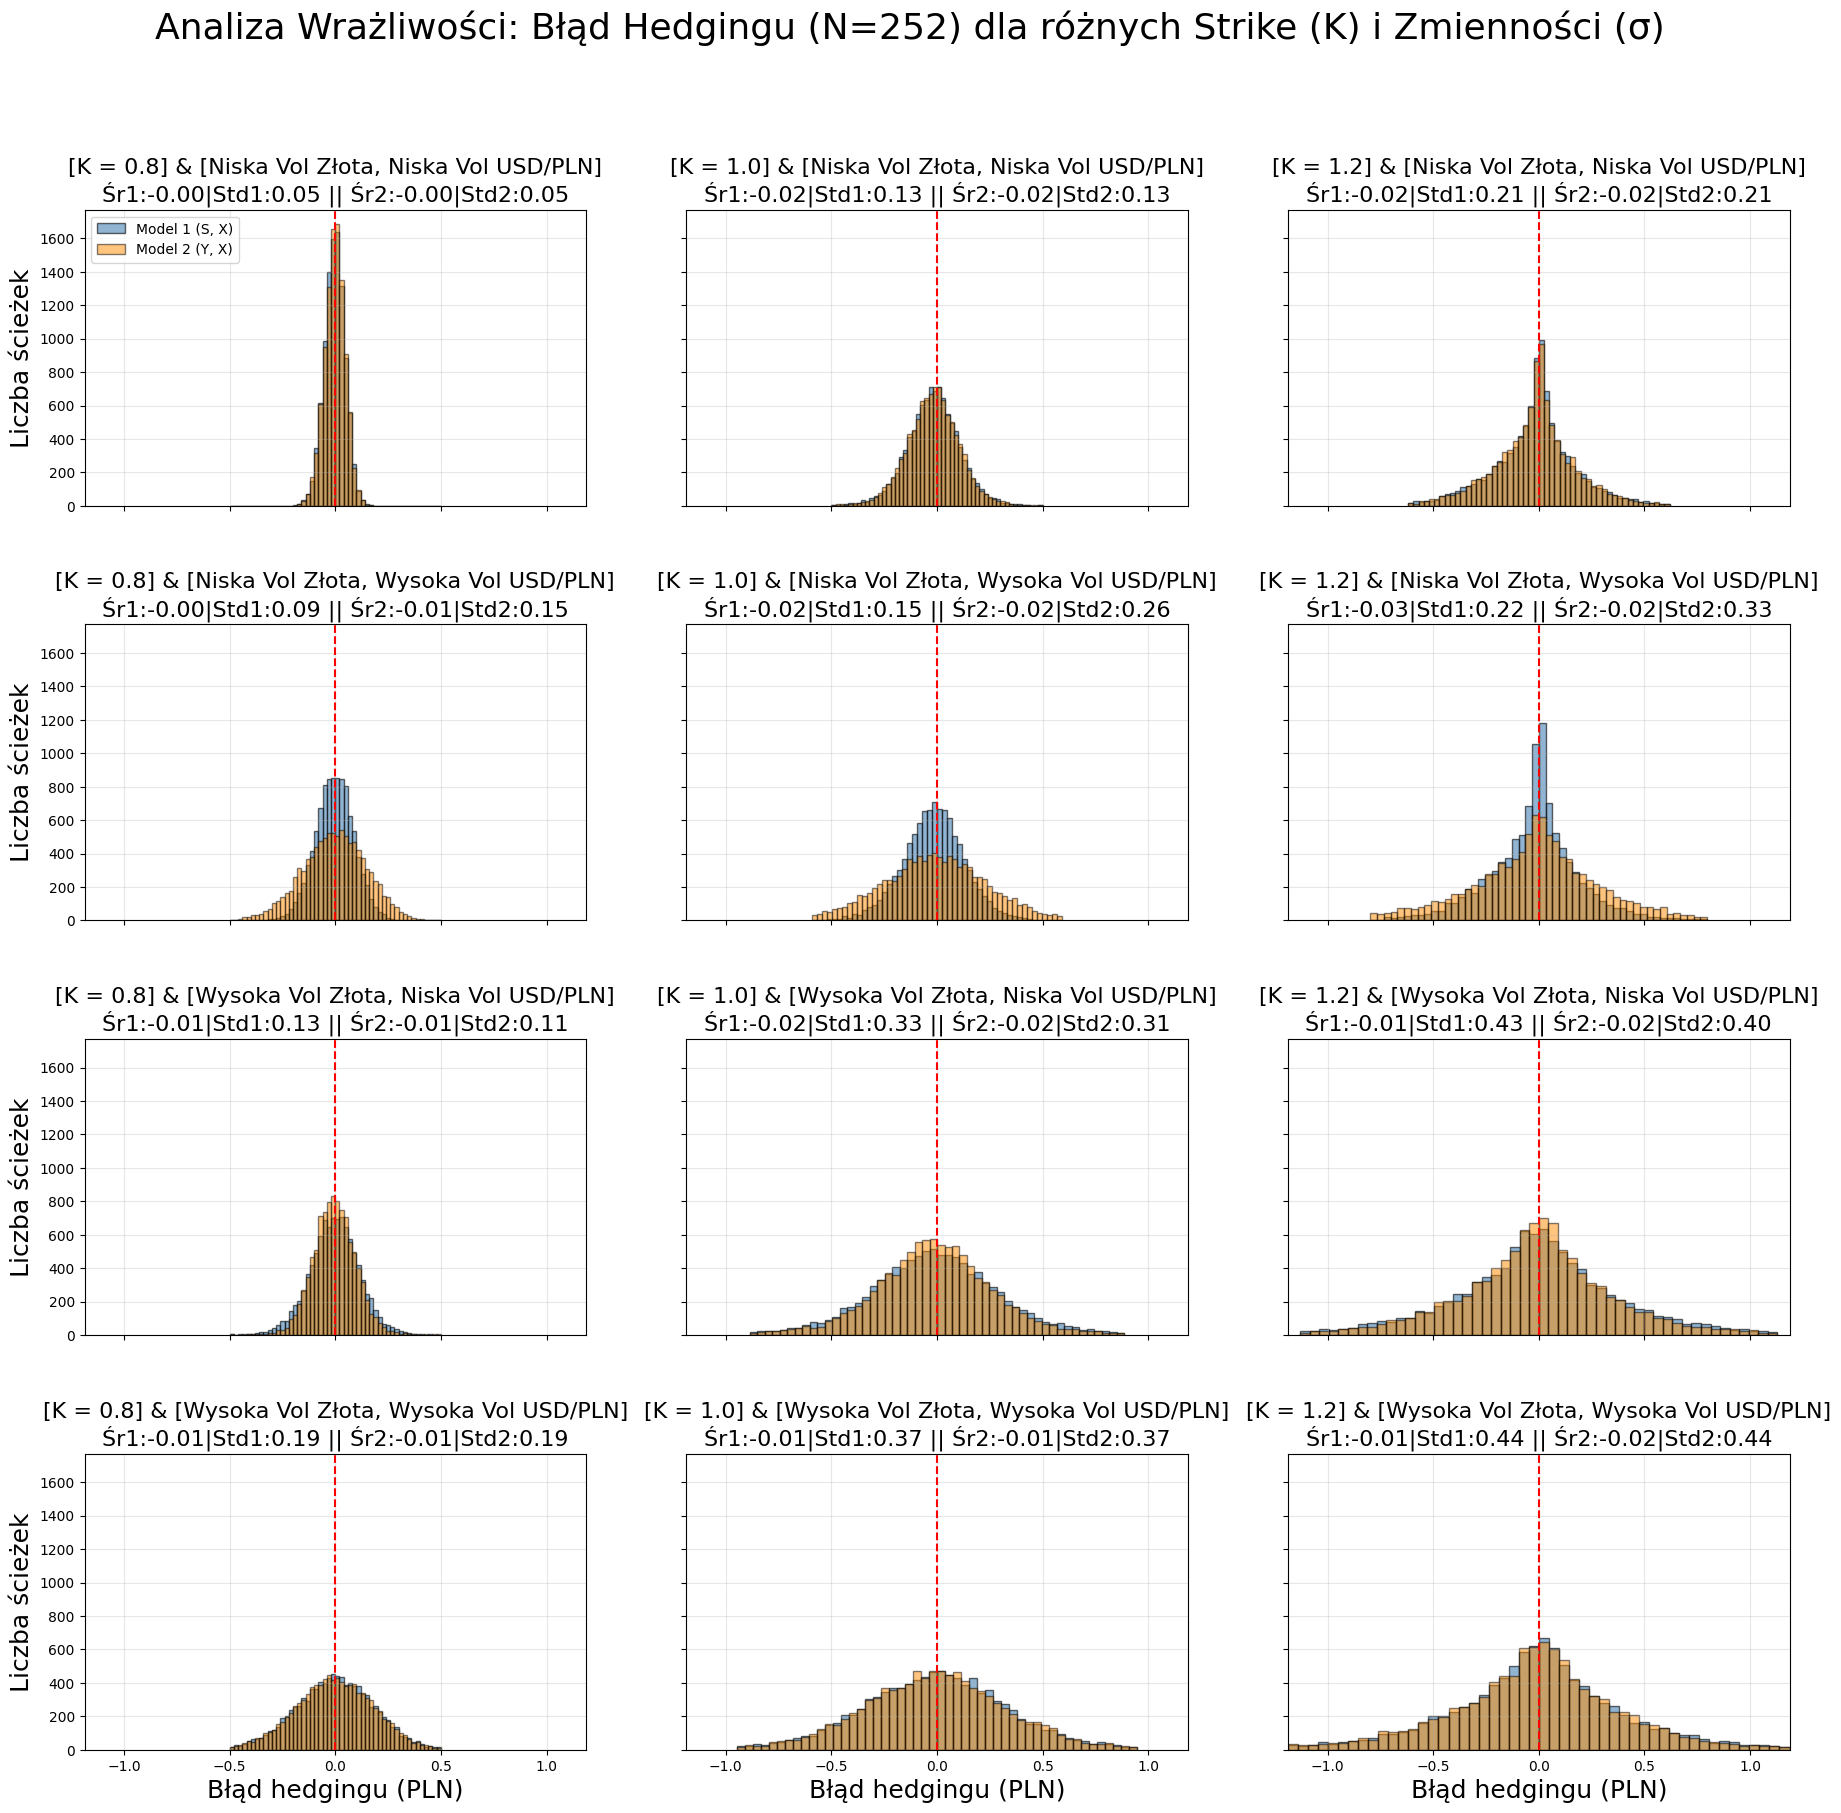

In [12]:

try:
    K_base = K
except NameError:
    K_base = 1.0  # domyślny mnożnik

N_val = 252 # Codzienny rehedging
dt_local = T / N_val
time_grid_local = np.linspace(0, T, N_val + 1)

# Definiujemy 3 wartości K (Kolumny)
K_mults = [0.8, 1.0, 1.2]
K_labels = ["K = 0.8", "K = 1.0", "K = 1.2"]

# Definiujemy 4 scenariusze zmienności [mnożnik Złota, mnożnik FX, Nazwa] (Wiersze)
vol_combinations = [
    (0.7, 0.7, "Niska Vol Złota, Niska Vol USD/PLN"),
    (0.7, 1.3, "Niska Vol Złota, Wysoka Vol USD/PLN"),
    (1.3, 0.7, "Wysoka Vol Złota, Niska Vol USD/PLN"),
    (1.3, 1.3, "Wysoka Vol Złota, Wysoka Vol USD/PLN")
]

fig, axes = plt.subplots(4, 3, figsize=(22, 20), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.4, wspace=0.2)


# Pętla po wierszach i kolumnach
for row, (m_gold, m_fx, vol_label) in enumerate(vol_combinations):
    
    # Skalujemy zmienności dla danego scenariusza
    s_gold_1 = sigma1 * m_gold
    s_fx     = sigma2 * m_fx
    s_gold_2 = sigma_Y_empiryczne * m_gold # Skalujemy też empiryczną zmienność Modelu 2
    
    for col, (k_m, k_label) in enumerate(zip(K_mults, K_labels)):
        K_strike = K_base * k_m
        
        # --- MODEL 1 ---
        np.random.seed(42 + row + col) # Zmieniamy seed dla każdego kwadratu, by były niezależne
        _, paths_S, paths_X_1 = simulate_correlated_paths(
            S0_gold, S0_usdpln, mu1, mu2, s_gold_1, s_fx, rho_SX, dt_local, T, n_paths
        )
        
        # --- MODEL 2 ---
        Y0 = S0_gold * S0_usdpln
        np.random.seed(42 + row + col)
        _, paths_Y, paths_X_2 = simulate_correlated_paths(
            Y0, S0_usdpln, mu_Y, mu2, s_gold_2, s_fx, rho_YX_empiryczne, dt_local, T, n_paths
        )
        
        # --- HEDGING 1 ---
        _, _, _, _, _, err_1, _, _, _ = simulate_delta_hedging(
            time_grid_local, paths_S, paths_X_1, S0_gold, K_strike, T, r_pln, r_usd, rho_SX, s_gold_1, s_fx, dt_local
        )
        bledy_1 = np.asarray(err_1).flatten()
        
        # --- HEDGING 2 ---
        _, _, _, _, _, err_2, _, _, _ = simulate_delta_hedging_2(
            time_grid_local, paths_Y, paths_X_2, S0_gold, K_strike, T, r_pln, r_usd, rho_YX_empiryczne, s_gold_2, s_fx, dt_local
        )
        bledy_2 = np.asarray(err_2).flatten()
        
        # --- RYSOWANIE ---
        ax = axes[row, col]
        
        # Odrzucamy ekstrema 1% dla czytelności osi X
        all_errors = np.concatenate([bledy_1, bledy_2])
        xmin = np.percentile(all_errors, 1)
        xmax = np.percentile(all_errors, 99)
        limit = max(abs(xmin), abs(xmax), 0.5) 
        
        ax.hist(bledy_1, bins=50, range=(-limit, limit), 
                 color='steelblue', edgecolor='black', alpha=0.6, label='Model 1 (S, X)')
        ax.hist(bledy_2, bins=50, range=(-limit, limit), 
                 color='darkorange', edgecolor='black', alpha=0.5, label='Model 2 (Y, X)')
        
        ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
        
        # Opisy
        ax.set_title(
            f'[{k_label}] & [{vol_label}]\n'
            f'Śr1:{np.mean(bledy_1):.2f}|Std1:{np.std(bledy_1):.2f} || '
            f'Śr2:{np.mean(bledy_2):.2f}|Std2:{np.std(bledy_2):.2f}',
            fontsize=16
        )
        
        ax.set_xlim(-limit, limit)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', labelsize=10)
        
        # Etykiety osi tylko na brzegach (żeby nie robić bałaganu)
        if col == 0:
            ax.set_ylabel('Liczba ścieżek', fontsize=18)
        if row == 3:
            ax.set_xlabel('Błąd hedgingu (PLN)', fontsize=18)
            
        if row == 0 and col == 0:
            ax.legend(fontsize=10, loc='upper left')


plt.suptitle('Analiza Wrażliwości: Błąd Hedgingu (N=252) dla różnych Strike (K) i Zmienności (σ)', fontsize=26, y=0.98)
plt.show()

Poniżej animacja

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

plt.close('all')

# ==========================================
# USTAWIENIA BAZOWE
# ==========================================
try:
    K_base = 1.0
except NameError:
    K_base = 1.0

# ==========================================
# SZTYWNE GRANICE OSI
# USTAW TUTAJ RĘCZNIE
# ==========================================
FIXED_X_LIMIT = 15   # zakres osi X: od -5000 do 5000
FIXED_Y_LIMIT = 5000   # zakres osi Y: od 0 do 1500
BINS = 100

# ==========================================
# FUNKCJA RYSUJĄCA
# ==========================================
def interactive_histogram_fixed_axes(N, K_mult, m_gold, m_fx, seed = 42):
    plt.close('all')
    
    # Parametry lokalne
    dt_local = T / N
    time_grid_local = np.linspace(0, T, N + 1)
    K_strike = K_base * K_mult

    # Skalowanie zmienności
    s_gold_1 = sigma1 * m_gold
    s_fx = sigma2 * m_fx
    s_gold_2 = sigma_Y_empiryczne * m_gold

    # ==========================================
    # MODEL 1
    # ==========================================
    np.random.seed(seed)
    _, paths_S, paths_X_1 = simulate_correlated_paths(
        S0_gold, S0_usdpln,
        mu1, mu2,
        s_gold_1, s_fx,
        rho_SX,
        dt_local, T, n_paths
    )

    # ==========================================
    # MODEL 2
    # ==========================================
    Y0 = S0_gold * S0_usdpln
    np.random.seed(seed)
    _, paths_Y, paths_X_2 = simulate_correlated_paths(
        Y0, S0_usdpln,
        mu_Y, mu2,
        s_gold_2, s_fx,
        rho_YX_empiryczne,
        dt_local, T, n_paths
    )

    # ==========================================
    # HEDGING MODEL 1
    # ==========================================
    _, _, _, _, _, err_1, _, _, _ = simulate_delta_hedging(
        time_grid_local,
        paths_S,
        paths_X_1,
        S0_gold,
        K_strike,
        T,
        r_pln,
        r_usd,
        rho_SX,
        s_gold_1,
        s_fx,
        dt_local
    )
    bledy_1 = np.asarray(err_1).flatten()

    # ==========================================
    # HEDGING MODEL 2
    # ==========================================
    _, _, _, _, _, err_2, _, _, _ = simulate_delta_hedging_2(
        time_grid_local,
        paths_Y,
        paths_X_2,
        S0_gold,
        K_strike,
        T,
        r_pln,
        r_usd,
        rho_YX_empiryczne,
        s_gold_2,
        s_fx,
        dt_local
    )
    bledy_2 = np.asarray(err_2).flatten()

    # ==========================================
    # RYSOWANIE
    # ==========================================
    fig, ax = plt.subplots(figsize=(12, 7))

    ax.hist(
        bledy_1,
        bins=BINS,
        range=(-FIXED_X_LIMIT, FIXED_X_LIMIT),
        color='steelblue',
        edgecolor='black',
        alpha=0.6,
        label='Model 1 (S, X)'
    )

    ax.hist(
        bledy_2,
        bins=BINS,
        range=(-FIXED_X_LIMIT, FIXED_X_LIMIT),
        color='darkorange',
        edgecolor='black',
        alpha=0.5,
        label='Model 2 (Y, X)'
    )

    ax.axvline(0, color='red', linestyle='--', linewidth=2)

    ax.set_title(
        f'Rozkład błędów hedgingu\n'
        f'N = {N},  K = {K_strike:.2f},  '
        f'm_gold = {m_gold:.2f},  m_fx = {m_fx:.2f},  seed = {seed}\n'
        f'Model 1 -> Śr: {np.mean(bledy_1):.2f} | Std: {np.std(bledy_1):.2f}\n'
        f'Model 2 -> Śr: {np.mean(bledy_2):.2f} | Std: {np.std(bledy_2):.2f}',
        fontsize=14
    )

    ax.set_xlabel('Błąd hedgingu (PLN)', fontsize=12)
    ax.set_ylabel('Liczba ścieżek', fontsize=12)

    # SZTYWNE OSIE
    ax.set_xlim(-FIXED_X_LIMIT, FIXED_X_LIMIT)
    ax.set_ylim(0, FIXED_Y_LIMIT)

    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12)
    ax.tick_params(axis='both', labelsize=11)

    plt.tight_layout()
    plt.show()


# ==========================================
# WIDGETY — WIĘCEJ OPCJI NIŻ WCZEŚNIEJ
# ==========================================
style = {'description_width': 'initial'}

dropdown_N = widgets.Dropdown(
    options=[
        ('Raz w roku (1)', 1),
        ('Co pół roku (2)', 2),
        ('Co kwartał (4)', 4),
        ('Co 2 miesiące (6)', 6),
        ('Co miesiąc (12)', 12),
        ('Co 2 tygodnie (24)', 24),
        ('Co tydzień (48)', 48),
        ('2x w tygodniu (96)', 96),
        ('Codziennie (252)', 252)
    ],
    value=252,
    description='Rehedging N:',
    style=style
)

slider_K = widgets.FloatSlider(
    value=1.0,
    min=0.5,
    max=1.5,
    step=0.05,
    description='K:',
    continuous_update=False,
    readout_format='.2f',
    style=style
)

slider_gold = widgets.FloatSlider(
    value=1.0,
    min=0.5,
    max=2.0,
    step=0.1,
    description='Multiplier vol złota:',
    continuous_update=False,
    readout_format='.2f',
    style=style
)

slider_fx = widgets.FloatSlider(
    value=1.0,
    min=0.5,
    max=2.0,
    step=0.1,
    description='Multiplier vol FX:',
    continuous_update=False,
    readout_format='.2f',
    style=style
)

# slider_seed = widgets.IntSlider(
#     value=42,
#     min=1,
#     max=200,
#     step=1,
#     description='Seed:',
#     continuous_update=False,
#     style=style
# )

ui = widgets.VBox([
    dropdown_N,
    slider_K,
    slider_gold,
    slider_fx,
    # slider_seed
])

out = widgets.interactive_output(
    interactive_histogram_fixed_axes,
    {
        'N': dropdown_N,
        'K_mult': slider_K,
        'm_gold': slider_gold,
        'm_fx': slider_fx,
        # 'seed': slider_seed
    }
)

display(ui, out)

Output()

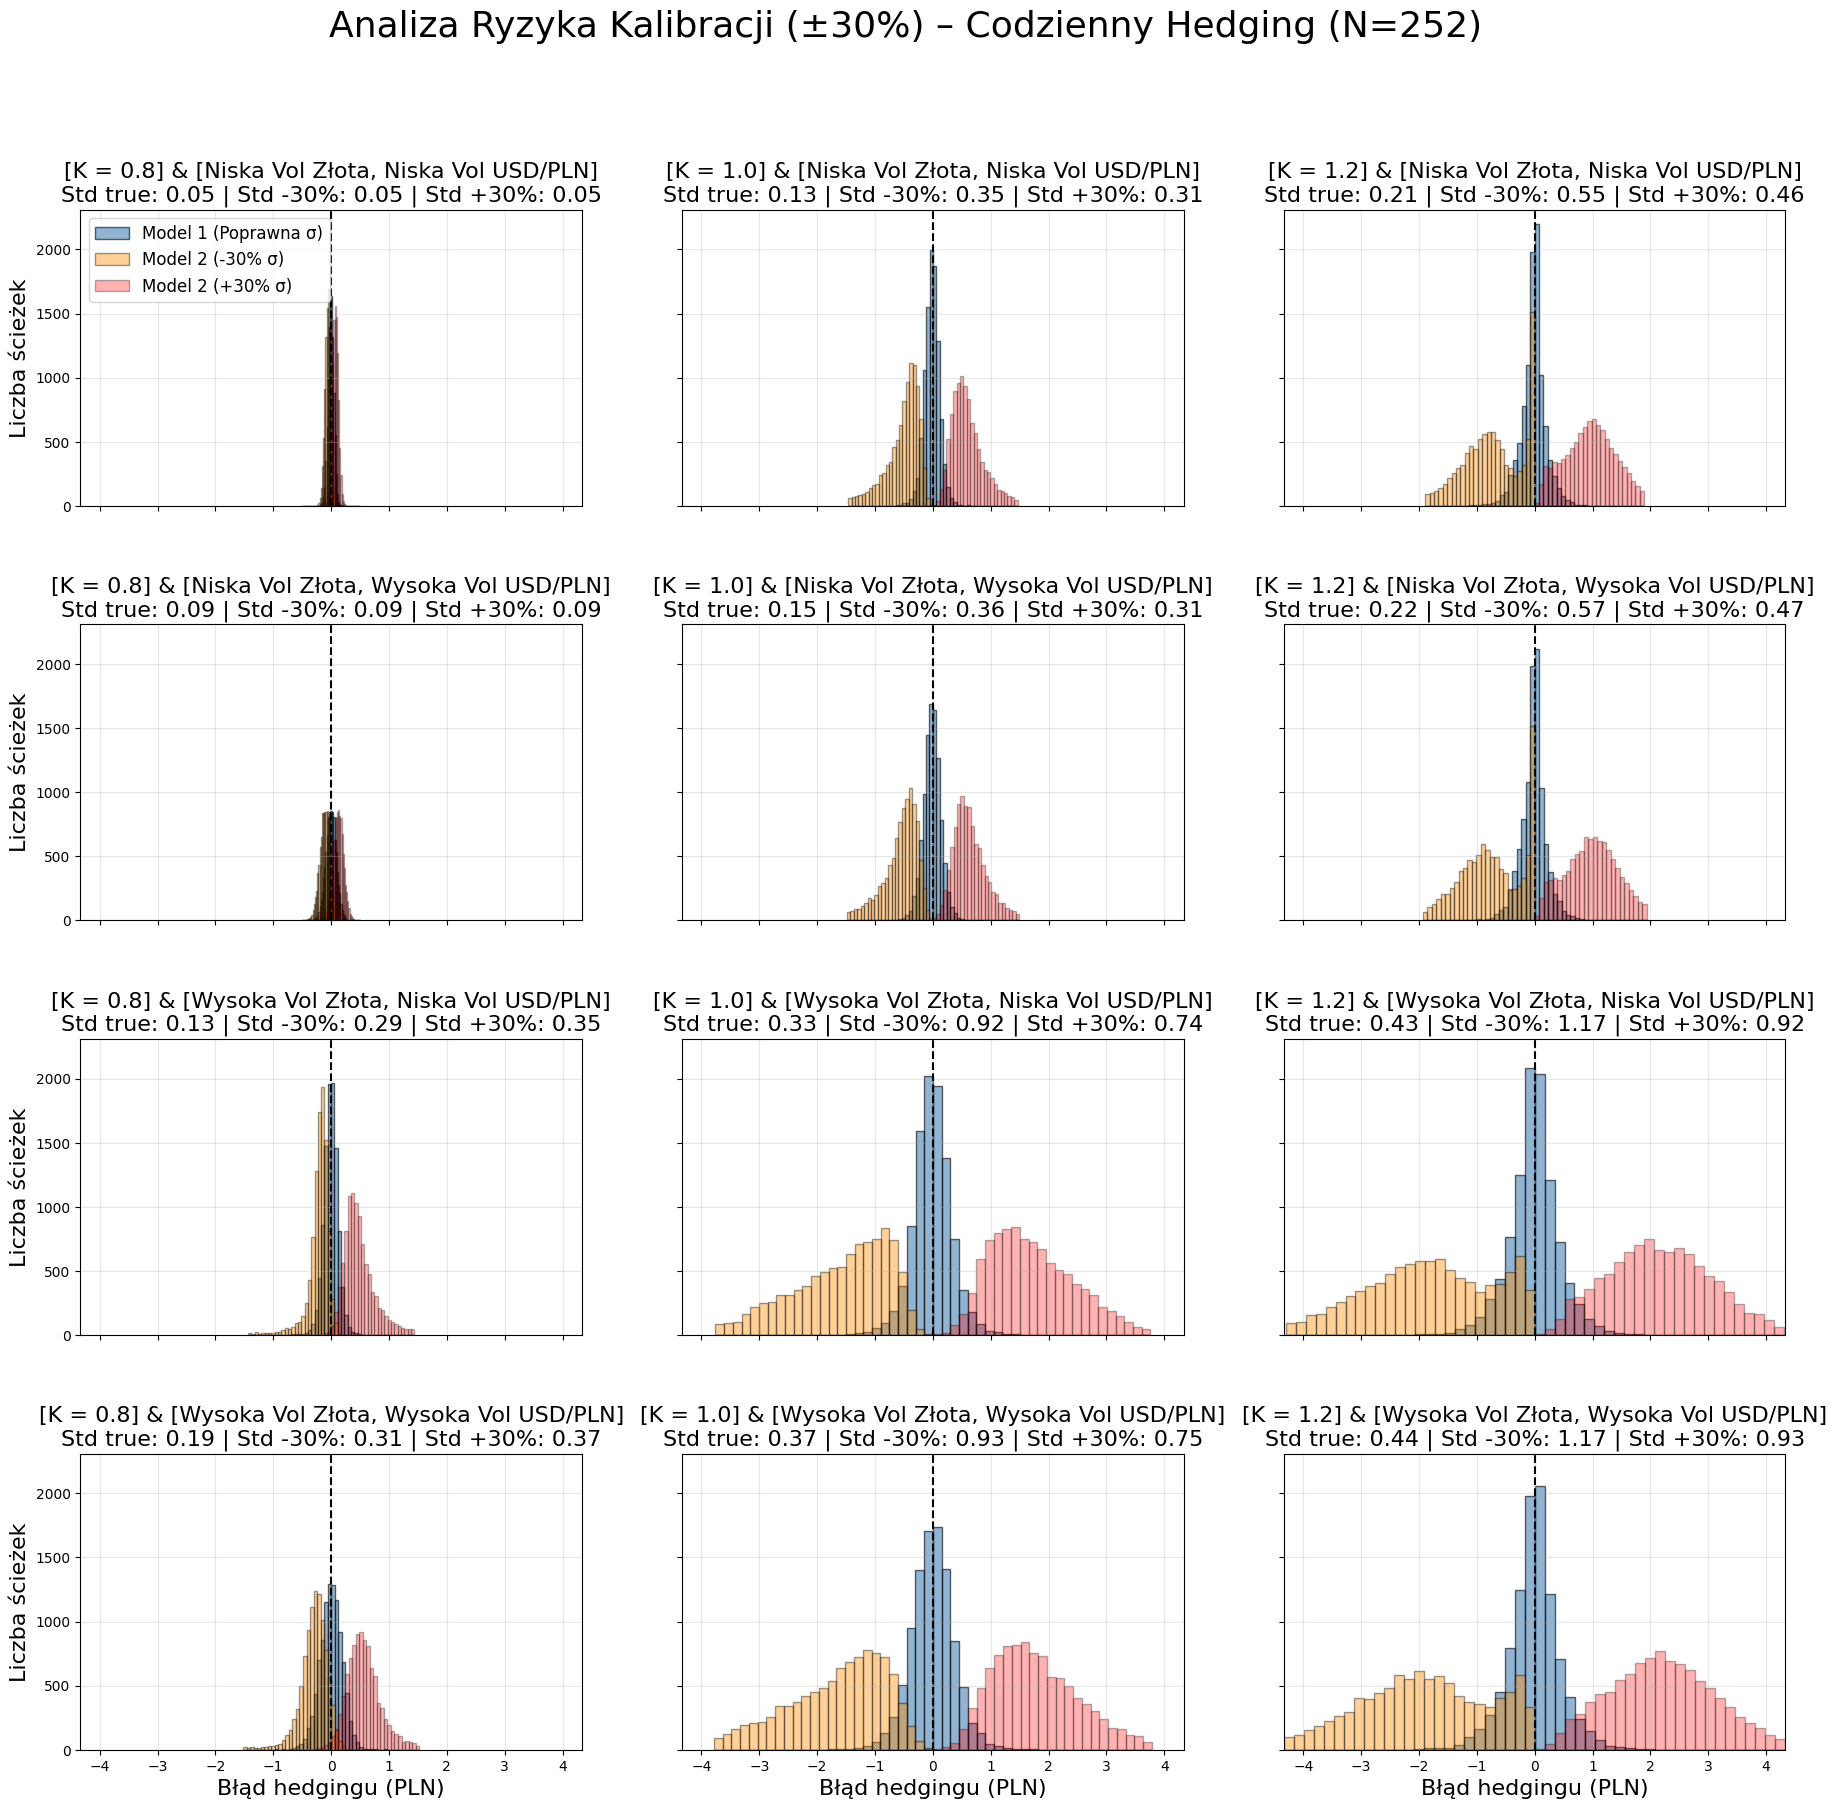

In [14]:

try:
    K_base = K
except NameError:
    K_base = 1.0

N_val = 252
dt_local = T / N_val
time_grid_local = np.linspace(0, T, N_val + 1)

K_mults = [0.8, 1.0, 1.2]
K_labels = ["K = 0.8", "K = 1.0", "K = 1.2"]

vol_combinations = [
    (0.7, 0.7, "Niska Vol Złota, Niska Vol USD/PLN"),
    (0.7, 1.3, "Niska Vol Złota, Wysoka Vol USD/PLN"),
    (1.3, 0.7, "Wysoka Vol Złota, Niska Vol USD/PLN"),
    (1.3, 1.3, "Wysoka Vol Złota, Wysoka Vol USD/PLN")
]

fig, axes = plt.subplots(4, 3, figsize=(22, 20), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.4, wspace=0.2)


for row, (m_gold, m_fx, vol_label) in enumerate(vol_combinations):
    
    # REALIZED zmienność rynku
    s_gold_real = sigma1 * m_gold
    s_fx_real   = sigma2 * m_fx
    
    for col, (k_m, k_label) in enumerate(zip(K_mults, K_labels)):
        K_strike = K_base * k_m
        
        
        # ==========================================
        # 1. GENERUJEMY PRAWDZIWY RYNEK
        # ==========================================
        np.random.seed(42 + row + col)
        _, paths_S, paths_X_1 = simulate_correlated_paths(
            S0_gold, S0_usdpln, mu1, mu2,
            s_gold_real, s_fx_real, rho_SX,
            dt_local, T, n_paths
        )
        
        # ==========================================
        # 2. MODEL 1 – poprawna kalibracja
        # ==========================================
        _, _, _, _, _, err_1, _, _, _ = simulate_delta_hedging(
            time_grid_local, paths_S, paths_X_1,
            S0_gold, K_strike, T,
            r_pln, r_usd, rho_SX,
            s_gold_real, s_fx_real,
            dt_local
        )
        bledy_1 = np.asarray(err_1).flatten()
        
        # ==========================================
        # 3. MODEL 2 – błędna kalibracja ±30%
        # ==========================================
        # -30%
        _, _, _, _, _, err_2_low, _, _, _ = simulate_delta_hedging(
            time_grid_local, paths_S, paths_X_1,
            S0_gold, K_strike, T,
            r_pln, r_usd, rho_SX,
            0.7 * s_gold_real, s_fx_real,
            dt_local
        )
        bledy_2_low = np.asarray(err_2_low).flatten()
        
        # +30%
        _, _, _, _, _, err_2_high, _, _, _ = simulate_delta_hedging(
            time_grid_local, paths_S, paths_X_1,
            S0_gold, K_strike, T,
            r_pln, r_usd, rho_SX,
            1.3 * s_gold_real, s_fx_real,
            dt_local
        )
        bledy_2_high = np.asarray(err_2_high).flatten()
        
        # ==========================================
        # RYSOWANIE
        # ==========================================
        ax = axes[row, col]
        
        all_errors = np.concatenate([bledy_1, bledy_2_low, bledy_2_high])
        xmin = np.percentile(all_errors, 1)
        xmax = np.percentile(all_errors, 99)
        limit = max(abs(xmin), abs(xmax), 0.5)
        
        ax.hist(bledy_1, bins=50, range=(-limit, limit),
                color='steelblue', edgecolor='black', alpha=0.6,
                label='Model 1 (Poprawna σ)')
        
        ax.hist(bledy_2_low, bins=50, range=(-limit, limit),
                color='darkorange', edgecolor='black', alpha=0.4,
                label='Model 2 (-30% σ)')
        
        ax.hist(bledy_2_high, bins=50, range=(-limit, limit),
                color='red', edgecolor='black', alpha=0.3,
                label='Model 2 (+30% σ)')
        
        ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
        
        ax.set_title(
            f'[{k_label}] & [{vol_label}]\n'
            f'Std true: {np.std(bledy_1):.2f} | '
            f'Std -30%: {np.std(bledy_2_low):.2f} | '
            f'Std +30%: {np.std(bledy_2_high):.2f}',
            fontsize=16
        )
        
        ax.set_xlim(-limit, limit)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', labelsize=10)
        
        if col == 0:
            ax.set_ylabel('Liczba ścieżek', fontsize=16)
        if row == 3:
            ax.set_xlabel('Błąd hedgingu (PLN)', fontsize=16)
        if row == 0 and col == 0:
            ax.legend(fontsize=12, loc='upper left')

plt.suptitle('Analiza Ryzyka Kalibracji (±30%) – Codzienny Hedging (N=252)', fontsize=26)
plt.show()

In [15]:
# ==========================================
# MODEL 1 z kosztami transakcyjnymi
# ==========================================
def delta_hedging_step_tc(S, X, delta_S_old, delta_X_old, cash_PLN,
                          S0, K, tau, r_pln, r_usd, rho, sigma_S, sigma_X, dt, tc_rate):
    
    cash_PLN = cash_PLN * np.exp(r_pln * dt)
    delta_X_old = delta_X_old * np.exp(r_usd * dt)

    Pi = delta_S_old * S * X + delta_X_old * X + cash_PLN

    d1, _ = d1_d2(S, S0, K, tau, r_usd, rho, sigma_S, sigma_X)
    q = r_pln - r_usd + rho * sigma_X * sigma_S
    dV_dS = (100 / S0) * np.exp(-q * tau) * norm.cdf(d1)

    delta_S_new = (1 / X) * dV_dS
    delta_X_new = -(S / X) * dV_dS

    # Koszt transakcji na złocie i USD (w PLN)
    # |zmiana pozycji| * cena instrumentu w PLN * stawka
    tc_S = tc_rate * np.abs(delta_S_new - delta_S_old) * S * X
    tc_X = tc_rate * np.abs(delta_X_new - delta_X_old) * X
    transaction_cost = tc_S + tc_X

    cash_PLN = cash_PLN - (delta_S_new - delta_S_old) * S * X - (delta_X_new - delta_X_old) * X - transaction_cost
    
    return delta_S_new, delta_X_new, cash_PLN, Pi


def simulate_delta_hedging_tc(time, S, X, S0, K, T, r_pln, r_usd, rho, sigma_S, sigma_X, dt, tc_rate=0.001):
    n_steps = len(time) - 1

    delta_S = np.zeros_like(S)
    delta_X = np.zeros_like(X)
    cash_PLN = np.zeros_like(S)
    Pi = np.zeros_like(S)

    V0 = quanto(S[0], S0, K, T, r_pln, r_usd, rho, sigma_S, sigma_X)
    
    delta_S[0], delta_X[0], cash_PLN[0], Pi[0] = delta_hedging_step_tc(
        S[0], X[0], 0, 0, V0, 
        S0, K, T, r_pln, r_usd, rho, sigma_S, sigma_X, 0, tc_rate
    )

    for i in range(1, n_steps):
        tau = T - time[i]
        delta_S[i], delta_X[i], cash_PLN[i], Pi[i] = delta_hedging_step_tc(
            S[i], X[i], delta_S[i-1], delta_X[i-1], cash_PLN[i-1],
            S0, K, tau, r_pln, r_usd, rho, sigma_S, sigma_X, dt, tc_rate
        )

    delta_S[-1] = delta_S[-2]
    delta_X[-1] = delta_X[-2] * np.exp(r_usd * dt)
    cash_PLN[-1] = cash_PLN[-2] * np.exp(r_pln * dt)
    
    Pi[-1] = delta_S[-1] * S[-1] * X[-1] + delta_X[-1] * X[-1] + cash_PLN[-1]
    
    payoff = 100 * np.maximum(S[-1]/S0 - K, 0)
    hedging_error = Pi[-1] - payoff

    return time, S, X, Pi, payoff, hedging_error, delta_S, delta_X, cash_PLN


# ==========================================
# MODEL 2 z kosztami transakcyjnymi
# ==========================================
def delta_hedging_step_2_tc(Y, X, delta_Y_old, delta_X_old, cash_PLN,
                            S0, K, tau, r_pln, r_usd, rho, sigma_Y, sigma_X, dt, tc_rate):
    
    cash_PLN = cash_PLN * np.exp(r_pln * dt)
    delta_X_old = delta_X_old * np.exp(r_usd * dt)

    Pi = delta_Y_old * Y + delta_X_old * X + cash_PLN

    q = r_pln - r_usd - sigma_X ** 2 + rho * sigma_Y * sigma_X
    sigma_z = np.sqrt(sigma_Y ** 2 + sigma_X ** 2 - 2 * rho * sigma_Y * sigma_X)
    r_hat = r_pln - q
    
    if tau <= 1e-12:
        dV_dY = 0
    else:
        d1 = (np.log(Y / (X * S0 * K)) + (r_hat + 0.5 * sigma_z ** 2) * tau) / (sigma_z * np.sqrt(tau))
        dV_dY = (100 / (X * S0)) * np.exp(-q * tau) * norm.cdf(d1)

    delta_Y_new = dV_dY
    delta_X_new = -(Y / X) * dV_dY

    # Koszt transakcji (Y jest już w PLN, X * 1 USD = X PLN)
    tc_Y = tc_rate * np.abs(delta_Y_new - delta_Y_old) * Y
    tc_X = tc_rate * np.abs(delta_X_new - delta_X_old) * X
    transaction_cost = tc_Y + tc_X

    cash_PLN = cash_PLN - (delta_Y_new - delta_Y_old) * Y - (delta_X_new - delta_X_old) * X - transaction_cost
    
    return delta_Y_new, delta_X_new, cash_PLN, Pi


def simulate_delta_hedging_2_tc(time, Y, X, S0, K, T, r_pln, r_usd, rho, sigma_Y, sigma_X, dt, tc_rate=0.001):
    n_steps = len(time) - 1

    delta_Y = np.zeros_like(Y)
    delta_X = np.zeros_like(X)
    cash_PLN = np.zeros_like(Y)
    Pi = np.zeros_like(Y)

    V0 = quanto_2(Y[0], X[0], S0, K, T, r_pln, r_usd, rho, sigma_Y, sigma_X)
    
    delta_Y[0], delta_X[0], cash_PLN[0], Pi[0] = delta_hedging_step_2_tc(
        Y[0], X[0], 0, 0, V0, 
        S0, K, T, r_pln, r_usd, rho, sigma_Y, sigma_X, 0, tc_rate
    )

    for i in range(1, n_steps):
        tau = T - time[i]
        delta_Y[i], delta_X[i], cash_PLN[i], Pi[i] = delta_hedging_step_2_tc(
            Y[i], X[i], delta_Y[i-1], delta_X[i-1], cash_PLN[i-1],
            S0, K, tau, r_pln, r_usd, rho, sigma_Y, sigma_X, dt, tc_rate
        )

    delta_Y[-1] = delta_Y[-2]
    delta_X[-1] = delta_X[-2] * np.exp(r_usd * dt)
    cash_PLN[-1] = cash_PLN[-2] * np.exp(r_pln * dt)
    
    Pi[-1] = delta_Y[-1] * Y[-1] + delta_X[-1] * X[-1] + cash_PLN[-1]
    
    payoff = 100 * np.maximum((Y[-1] / X[-1]) / S0 - K, 0)
    hedging_error = Pi[-1] - payoff

    return time, Y, X, Pi, payoff, hedging_error, delta_Y, delta_X, cash_PLN

In [16]:
TC_RATE = 0.001 

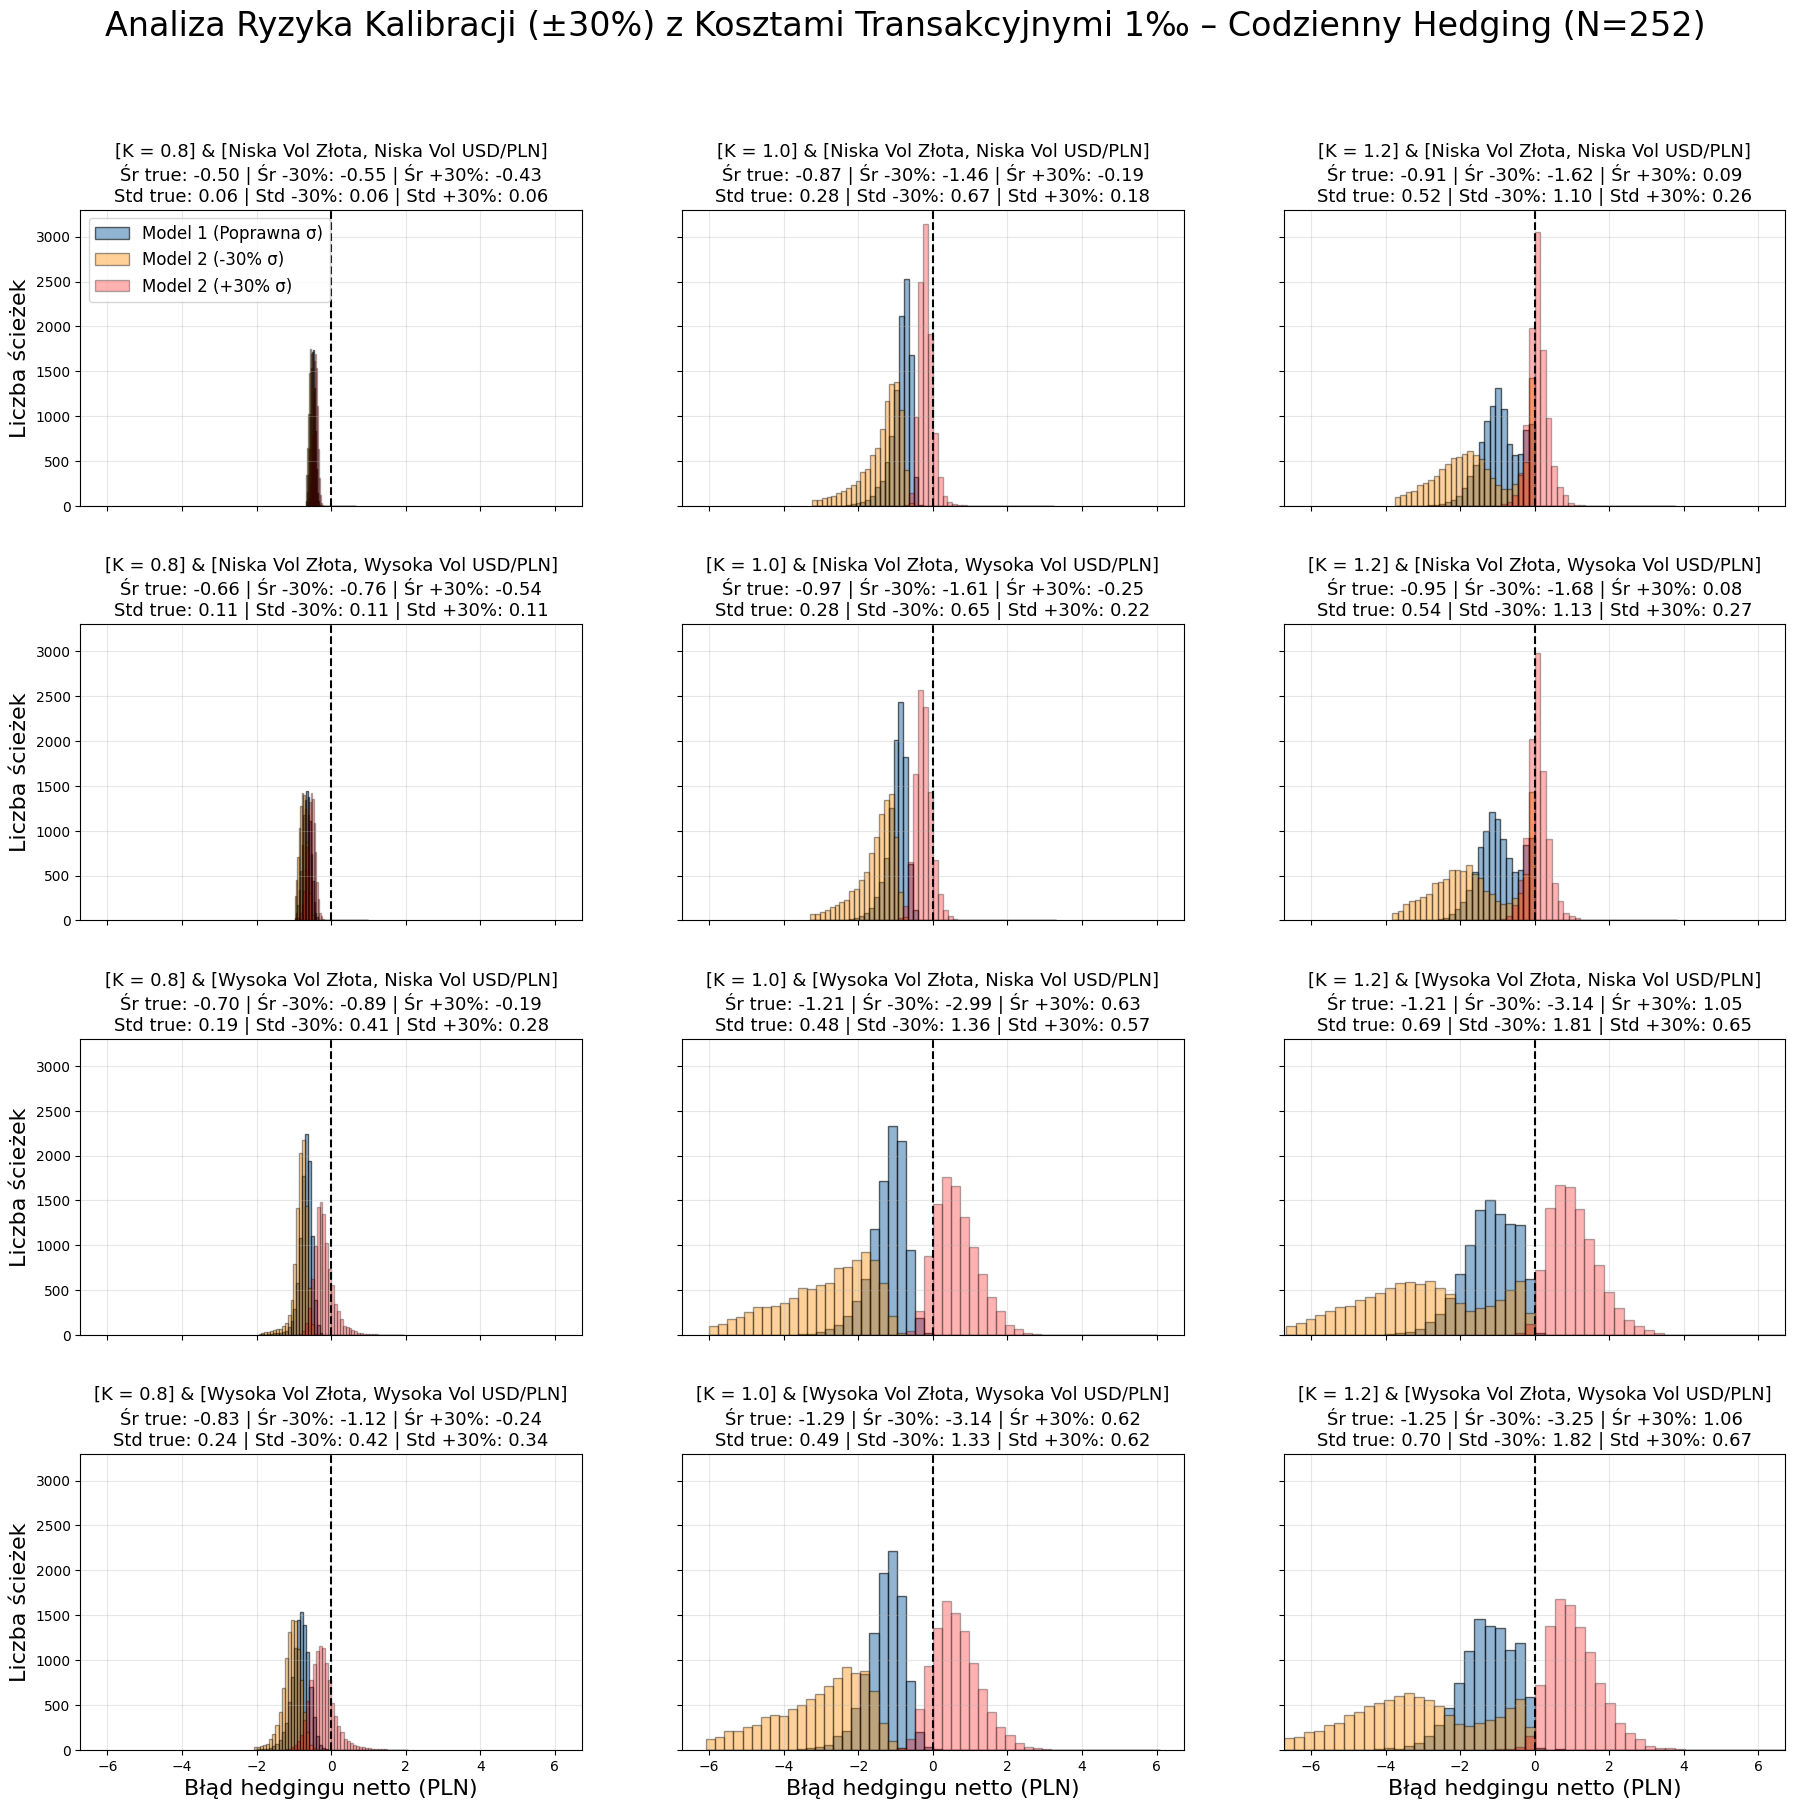

In [17]:

try:
    K_base = K
except NameError:
    K_base = 1.0

N_val = 252
dt_local = T / N_val
time_grid_local = np.linspace(0, T, N_val + 1)

 # 1 promil

K_mults = [0.8, 1.0, 1.2]
K_labels = ["K = 0.8", "K = 1.0", "K = 1.2"]

vol_combinations = [
    (0.7, 0.7, "Niska Vol Złota, Niska Vol USD/PLN"),
    (0.7, 1.3, "Niska Vol Złota, Wysoka Vol USD/PLN"),
    (1.3, 0.7, "Wysoka Vol Złota, Niska Vol USD/PLN"),
    (1.3, 1.3, "Wysoka Vol Złota, Wysoka Vol USD/PLN")
]

fig, axes = plt.subplots(4, 3, figsize=(22, 20), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.4, wspace=0.2)

for row, (m_gold, m_fx, vol_label) in enumerate(vol_combinations):
    
    s_gold_real = sigma1 * m_gold
    s_fx_real   = sigma2 * m_fx
    
    for col, (k_m, k_label) in enumerate(zip(K_mults, K_labels)):
        K_strike = K_base * k_m
        
        # 1. Rynek
        np.random.seed(42 + row + col)
        _, paths_S, paths_X_1 = simulate_correlated_paths(
            S0_gold, S0_usdpln, mu1, mu2,
            s_gold_real, s_fx_real, rho_SX,
            dt_local, T, n_paths
        )
        
        # 2. Model 1 - poprawna sigma
        _, _, _, _, _, err_1, _, _, _ = simulate_delta_hedging_tc(
            time_grid_local, paths_S, paths_X_1,
            S0_gold, K_strike, T,
            r_pln, r_usd, rho_SX,
            s_gold_real, s_fx_real,
            dt_local, tc_rate=TC_RATE
        )
        bledy_1 = np.asarray(err_1).flatten()
        
        # 3. Model 2 -30%
        _, _, _, _, _, err_2_low, _, _, _ = simulate_delta_hedging_tc(
            time_grid_local, paths_S, paths_X_1,
            S0_gold, K_strike, T,
            r_pln, r_usd, rho_SX,
            0.7 * s_gold_real, s_fx_real,
            dt_local, tc_rate=TC_RATE
        )
        bledy_2_low = np.asarray(err_2_low).flatten()
        
        # 4. Model 2 +30%
        _, _, _, _, _, err_2_high, _, _, _ = simulate_delta_hedging_tc(
            time_grid_local, paths_S, paths_X_1,
            S0_gold, K_strike, T,
            r_pln, r_usd, rho_SX,
            1.3 * s_gold_real, s_fx_real,
            dt_local, tc_rate=TC_RATE
        )
        bledy_2_high = np.asarray(err_2_high).flatten()
        
        # RYSOWANIE
        ax = axes[row, col]
        
        all_errors = np.concatenate([bledy_1, bledy_2_low, bledy_2_high])
        xmin = np.percentile(all_errors, 1)
        xmax = np.percentile(all_errors, 99)
        limit = max(abs(xmin), abs(xmax), 0.5)
        
        ax.hist(bledy_1, bins=50, range=(-limit, limit),
                color='steelblue', edgecolor='black', alpha=0.6,
                label='Model 1 (Poprawna σ)')
        ax.hist(bledy_2_low, bins=50, range=(-limit, limit),
                color='darkorange', edgecolor='black', alpha=0.4,
                label='Model 2 (-30% σ)')
        ax.hist(bledy_2_high, bins=50, range=(-limit, limit),
                color='red', edgecolor='black', alpha=0.3,
                label='Model 2 (+30% σ)')
        
        ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
        
        ax.set_title(
            f'[{k_label}] & [{vol_label}]\n'
            f'Śr true: {np.mean(bledy_1):.2f} | Śr -30%: {np.mean(bledy_2_low):.2f} | Śr +30%: {np.mean(bledy_2_high):.2f}\n'
            f'Std true: {np.std(bledy_1):.2f} | Std -30%: {np.std(bledy_2_low):.2f} | Std +30%: {np.std(bledy_2_high):.2f}',
            fontsize=13
        )
        
        ax.set_xlim(-limit, limit)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', labelsize=10)
        
        if col == 0:
            ax.set_ylabel('Liczba ścieżek', fontsize=16)
        if row == 3:
            ax.set_xlabel('Błąd hedgingu netto (PLN)', fontsize=16)
        if row == 0 and col == 0:
            ax.legend(fontsize=12, loc='upper left')

plt.suptitle(
    f'Analiza Ryzyka Kalibracji (±30%) z Kosztami Transakcyjnymi {TC_RATE*1000:.0f}‰ – Codzienny Hedging (N=252)',
    fontsize=24
)
plt.show()

# Tutaj koniec mojej części

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd

np.random.seed(42)
# w chwili 0:
def price1(K, r_pln, r_usd, rho, sigma_x, sigma_s, t=0, T=1, C=100):
    q = r_pln - r_usd + rho * sigma_s * sigma_x
    r_hat = r_pln - q
    d1 = (-np.log(K) + (r_hat + 0.5 * sigma_s ** 2) * (T-t)) / (sigma_s * np.sqrt(T-t))
    d2 = d1 - sigma_s * np.sqrt(T-t)

    cena = C * (np.exp((-q) * (T-t)) * norm.cdf(d1) - K * np.exp(-r_pln * (T-t)) * norm.cdf(d2))
    return cena

# w chwili 0:
def price2(K, r_pln, r_usd, sigma_y, sigma_x, rho, t=0, T=1, C=100):
    q = r_pln - r_usd - sigma_x ** 2 + rho * sigma_y * sigma_x
    sigma_z = np.sqrt(sigma_y ** 2 + sigma_x ** 2 - 2 * rho * sigma_y * sigma_x)
    r_hat = r_pln - q

    d1 = (-np.log(K) + (r_hat + 0.5 * sigma_z ** 2) * (T-t)) / (sigma_z * np.sqrt(T-t))
    d2 = d1 - sigma_z * np.sqrt(T-t)

    cena = C * (np.exp((-q) * (T-t)) * norm.cdf(d1) - K * np.exp(-r_pln * (T-t)) * norm.cdf(d2))
    return cena

# parametry bazowe:
T, K = 1, 1
mu_S = 0.2062
mu_X = -0.0169
mu_Y = 0.1893
sigma_S = 0.1289
sigma_X = 0.1042
sigma_Y = 0.1439

rho_SX = -0.2525
rho_XY = 0.4981

r_PLN = 0.05
r_USD = 0.042

In [19]:
# wycena dla różnych K:
K_values = [0.5, 0.75, 1, 1.25, 1.5]
prices1 = [price1(k, r_PLN, r_USD, rho_SX, sigma_X, sigma_S) for k in K_values]
prices2 = [price2(k, r_PLN, r_USD, sigma_Y, sigma_X, rho_XY) for k in K_values]
roznice = [prices1[i] - prices2[i] for i in range(len(prices1))]

wycena_opcji = pd.DataFrame({
    "K": K_values,
    "Cena opcji - model 1": prices1,
    "Cena opcji - model 2": prices2,
    "Różnica": roznice
})
#wycena_opcji = wycena_opcji.round(5)
print(wycena_opcji)

      K  Cena opcji - model 1  Cena opcji - model 2   Różnica
0  0.50             51.978731             51.978484  0.000247
1  0.75             28.214699             28.214509  0.000190
2  1.00              7.516776              7.518340 -0.001565
3  1.25              0.537679              0.538450 -0.000771
4  1.50              0.011931              0.011976 -0.000045


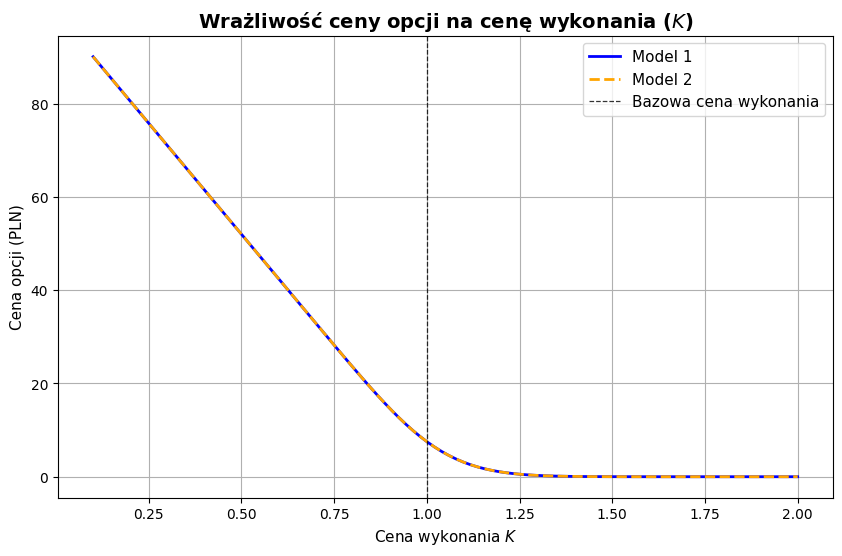

In [20]:
K_values = np.linspace(0.1, 2.0, 100)

prices_k1 = [price1(k, r_PLN, r_USD, rho_SX, sigma_X, sigma_S) for k in K_values]
prices_k2 = [price2(k, r_PLN, r_USD, sigma_Y, sigma_X, rho_XY) for k in K_values]

plt.figure(figsize = (10,6))
plt.plot(K_values, prices_k1, label='Model 1', color='blue', linewidth=2)
plt.plot(K_values, prices_k2, label='Model 2', color='orange', linestyle='--', linewidth=2)
plt.axvline(x=K, color='black', linestyle='--', alpha=0.8, linewidth=0.9, label='Bazowa cena wykonania')
plt.title('Wrażliwość ceny opcji na cenę wykonania ($K$)', fontsize=14, fontweight='bold')
plt.xlabel('Cena wykonania $K$', fontsize=11)
plt.ylabel('Cena opcji (PLN)', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True)
#plt.savefig("plots/wrazliwosc_K.png")
plt.show()

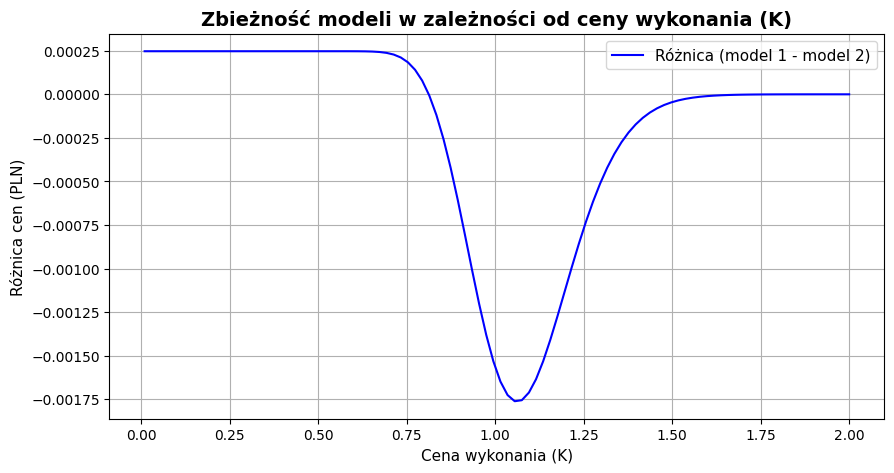

In [ ]:

K_range = np.linspace(0.01, 2.0, 100)

diffs_K = []
for k in K_range:
    p1 = price1(k, r_PLN, r_USD, rho_SX, sigma_X, sigma_S)
    p2 = price2(k, r_PLN, r_USD, sigma_Y, sigma_X, rho_XY)
    diffs_K.append(p1 - p2)

plt.figure(figsize=(10, 5))
plt.plot(K_range, diffs_K, color='blue', label='Różnica (model 1 - model 2)')
plt.title('Zbieżność modeli w zależności od ceny wykonania (K)', fontweight='bold', fontsize=14)
plt.xlabel('Cena wykonania (K)', fontsize=11)
plt.ylabel('Różnica cen (PLN)', fontsize=11)
plt.grid(True)
plt.legend(fontsize=11)
plt.show()

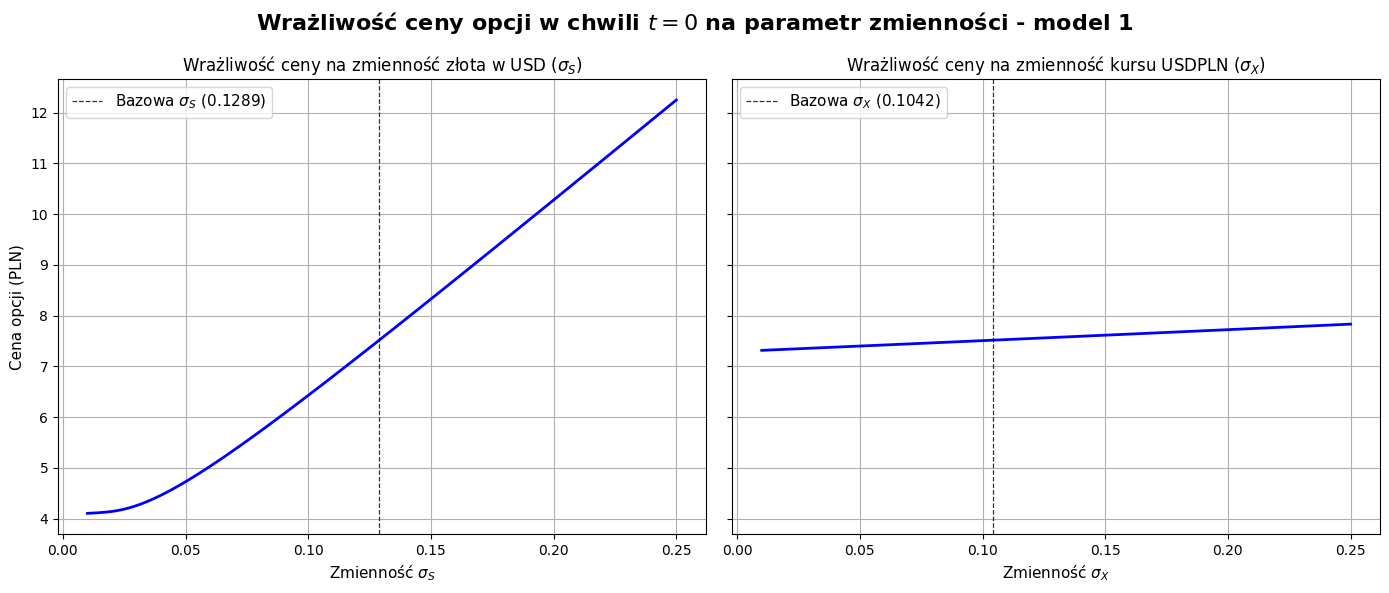

In [24]:
sigma_values = np.linspace(0.01, 0.25, 100)

prices_sigma_S = [] # zmieniamy sigma_S, a sigma_X jest stałe
prices_sigma_X = [] # zmieniamy sigma_X, a sigma_S jest stałe

for sigma in sigma_values:
    p_s = price1(K, r_PLN, r_USD, rho_SX, sigma_X, sigma)
    prices_sigma_S.append(p_s)

    p_x = price1(K, r_PLN, r_USD, rho_SX, sigma, sigma_S)
    prices_sigma_X.append(p_x)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# wykres - wrażliwość na sigma_S
ax1.plot(sigma_values, prices_sigma_S, color='blue', linewidth=2)
ax1.axvline(x=sigma_S, color='black', linestyle='--', alpha=0.8, linewidth=0.9,
            label=f'Bazowa $\\sigma_S$ ({sigma_S:.4f})')
ax1.set_title('Wrażliwość ceny na zmienność złota w USD ($\\sigma_S$)', fontsize=12)
ax1.set_xlabel('Zmienność $\\sigma_S$', fontsize=11)
ax1.set_ylabel('Cena opcji (PLN)', fontsize=11)
ax1.grid(True)
ax1.legend(loc='upper left', fontsize=11)

# wykres - wrażliwość na sigma_X
ax2.plot(sigma_values, prices_sigma_X, color='blue', linewidth=2)
ax2.axvline(x=sigma_X, color='black', linestyle='--', alpha=0.8, linewidth=0.9,
            label=f'Bazowa $\\sigma_X$ ({sigma_X:.4f})')
ax2.set_title('Wrażliwość ceny na zmienność kursu USDPLN ($\\sigma_X$)', fontsize=12)
ax2.set_xlabel('Zmienność $\\sigma_X$', fontsize=11)
ax2.grid(True)
ax2.legend(loc='upper left', fontsize=11)

plt.suptitle('Wrażliwość ceny opcji w chwili $t=0$ na parametr zmienności - model 1',
             fontsize=16, fontweight='bold')
plt.tight_layout()
#plt.savefig('plots/wrazliwosc_sigma_model1.png')
plt.show()

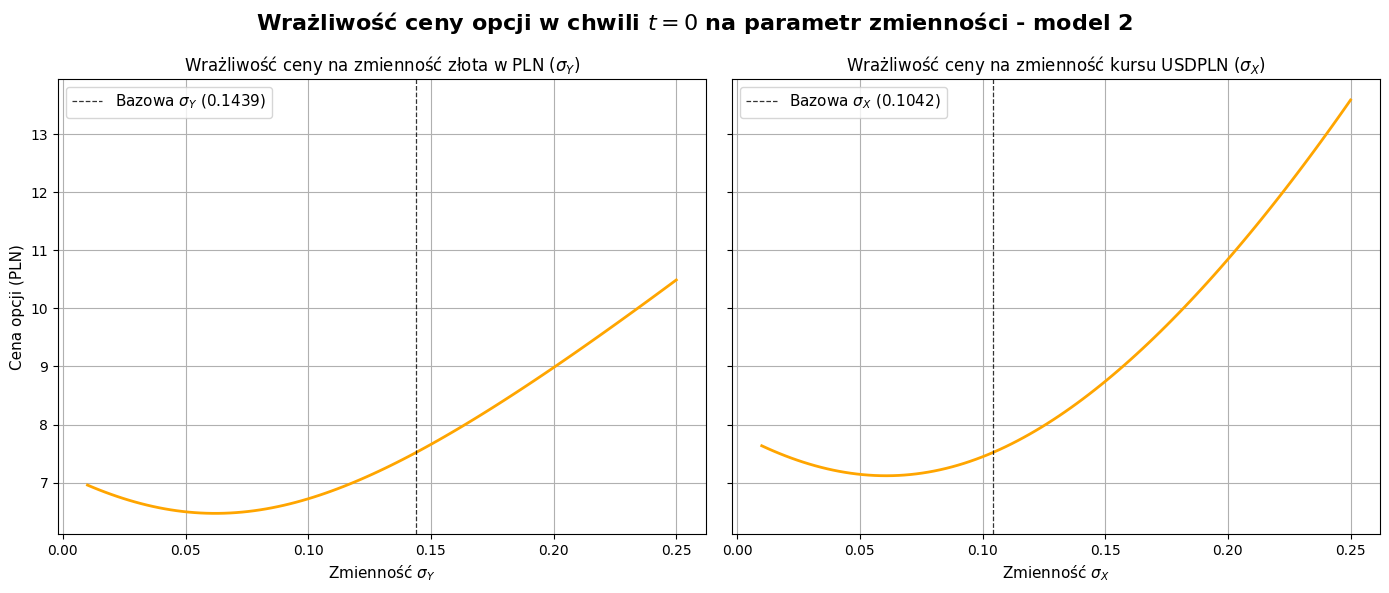

In [25]:
sigma_values2 = np.linspace(0.01, 0.25, 100)

prices_sigma_Y = [] # zmieniamy sigma_Y, a sigma_X jest stałe
prices_sigma_X_2 = [] # zmieniamy sigma_X, a sigma_Y jest stałe

for sigma in sigma_values2:
    p_y = price2(K, r_PLN, r_USD, sigma, sigma_X, rho_XY)
    prices_sigma_Y.append(p_y)

    p_x = price2(K, r_PLN, r_USD, sigma_Y, sigma, rho_XY)
    prices_sigma_X_2.append(p_x)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# wykres - wrażliwość na sigma_Y
ax1.plot(sigma_values, prices_sigma_Y, color='orange', linewidth=2)
ax1.axvline(x=sigma_Y, color='black', linestyle='--', alpha=0.8, linewidth=0.9,
            label=f'Bazowa $\\sigma_Y$ ({sigma_Y:.4f})')
ax1.set_title('Wrażliwość ceny na zmienność złota w PLN ($\\sigma_Y$)', fontsize=12)
ax1.set_xlabel('Zmienność $\\sigma_Y$', fontsize=11)
ax1.set_ylabel('Cena opcji (PLN)', fontsize=11)
ax1.grid(True)
ax1.legend(loc='upper left', fontsize=11)

# wykres - wrażliwość na sigma_X
ax2.plot(sigma_values, prices_sigma_X_2, color='orange', linewidth=2)
ax2.axvline(x=sigma_X, color='black', linestyle='--', alpha=0.8, linewidth=0.9,
            label=f'Bazowa $\\sigma_X$ ({sigma_X:.4f})')
ax2.set_title('Wrażliwość ceny na zmienność kursu USDPLN ($\\sigma_X$)', fontsize=12)
ax2.set_xlabel('Zmienność $\\sigma_X$', fontsize=11)
ax2.grid(True)
ax2.legend(loc='upper left', fontsize=11)

plt.suptitle('Wrażliwość ceny opcji w chwili $t=0$ na parametr zmienności - model 2',
             fontsize=16, fontweight='bold')
plt.tight_layout()
#plt.savefig('plots/wrazliwosc_sigma_model2.png')
plt.show()

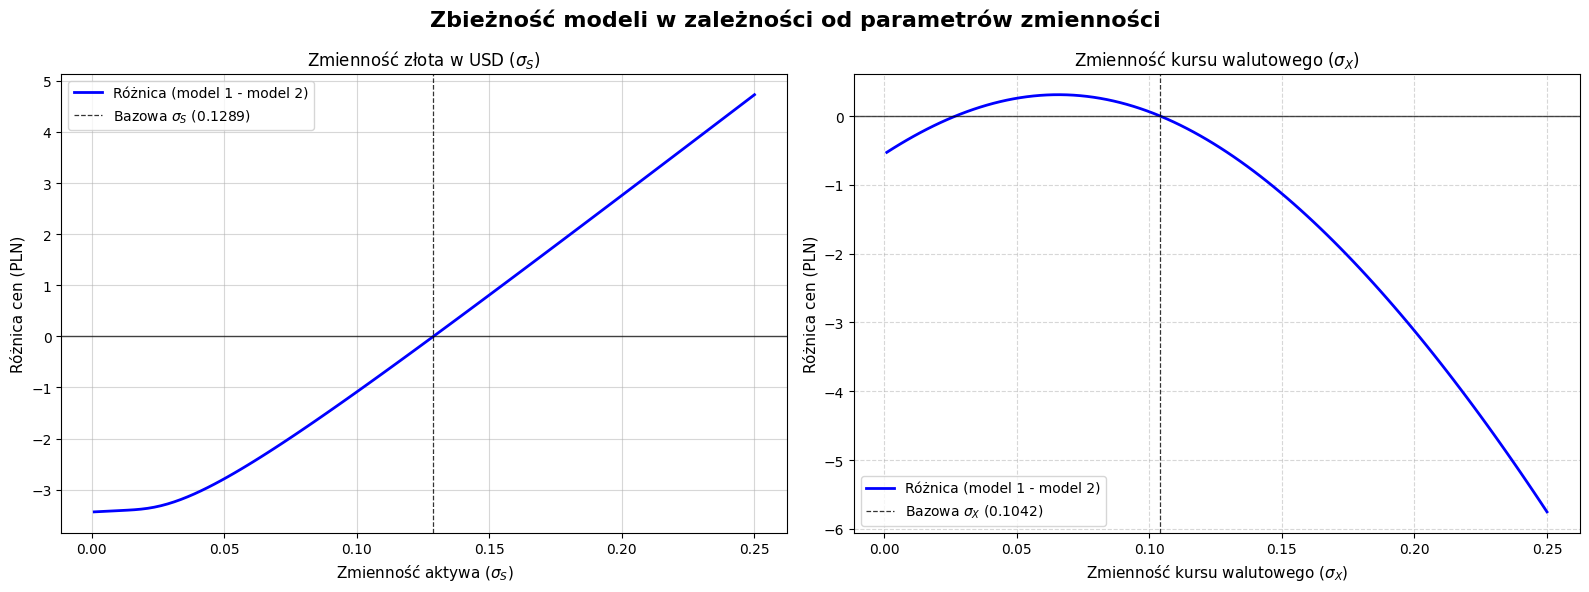

In [26]:
sigma_s_range = np.linspace(0.001, 0.25, 100)
diffs_sigma_s = []
for sigma_s in sigma_s_range:
    p1 = price1(K, r_PLN, r_USD, rho_SX, sigma_X, sigma_s)
    p2 = price2(K, r_PLN, r_USD, sigma_Y, sigma_X, rho_XY)
    diffs_sigma_s.append(p1 - p2)

# Dane do drugiego wykresu (zmienna zmienność kursu sigma_X)
sigma_x_range = np.linspace(0.001, 0.25, 100)
diffs_sigma_x = []
for sigma_x in sigma_x_range:
    p1 = price1(K, r_PLN, r_USD, rho_SX, sigma_x, sigma_S)
    p2 = price2(K, r_PLN, r_USD, sigma_Y, sigma_x, rho_XY)
    diffs_sigma_x.append(p1 - p2)

# ==========================================
# 2. RYSOWANIE WYKRESÓW OBOK SIEBIE
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- LEWY WYKRES (sigma_S) ---
ax1.plot(sigma_s_range, diffs_sigma_s, label='Różnica (model 1 - model 2)', color='blue', linewidth=2)
ax1.axvline(x=sigma_S, color='black', linestyle='--', alpha=0.8, linewidth=0.9, label=f'Bazowa $\\sigma_S$ ({sigma_S:.4f})')
ax1.axhline(y=0, color='black', linestyle='solid', linewidth=1.0, alpha=0.7)
ax1.set_title('Zmienność złota w USD ($\\sigma_{S}$)', fontsize=12)
ax1.set_xlabel('Zmienność aktywa ($\\sigma_S$)', fontsize=11)
ax1.set_ylabel('Różnica cen (PLN)', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.5)

# --- PRAWY WYKRES (sigma_X) ---
ax2.plot(sigma_x_range, diffs_sigma_x, label='Różnica (model 1 - model 2)', color='blue', linewidth=2)
ax2.axvline(x=sigma_X, color='black', linestyle='--', alpha=0.8, linewidth=0.9, label=f'Bazowa $\\sigma_X$ ({sigma_X:.4f})')
ax2.axhline(y=0, color='black', linestyle='solid', linewidth=1.0, alpha=0.7)
ax2.set_title('Zmienność kursu walutowego ($\\sigma_{X}$)', fontsize=12)
ax2.set_xlabel('Zmienność kursu walutowego ($\\sigma_X$)', fontsize=11)
ax2.set_ylabel('Różnica cen (PLN)', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)
plt.suptitle("Zbieżność modeli w zależności od parametrów zmienności", fontweight='bold', fontsize=16)
# Dopasowanie marginesów i wyświetlenie
plt.tight_layout()
plt.show()

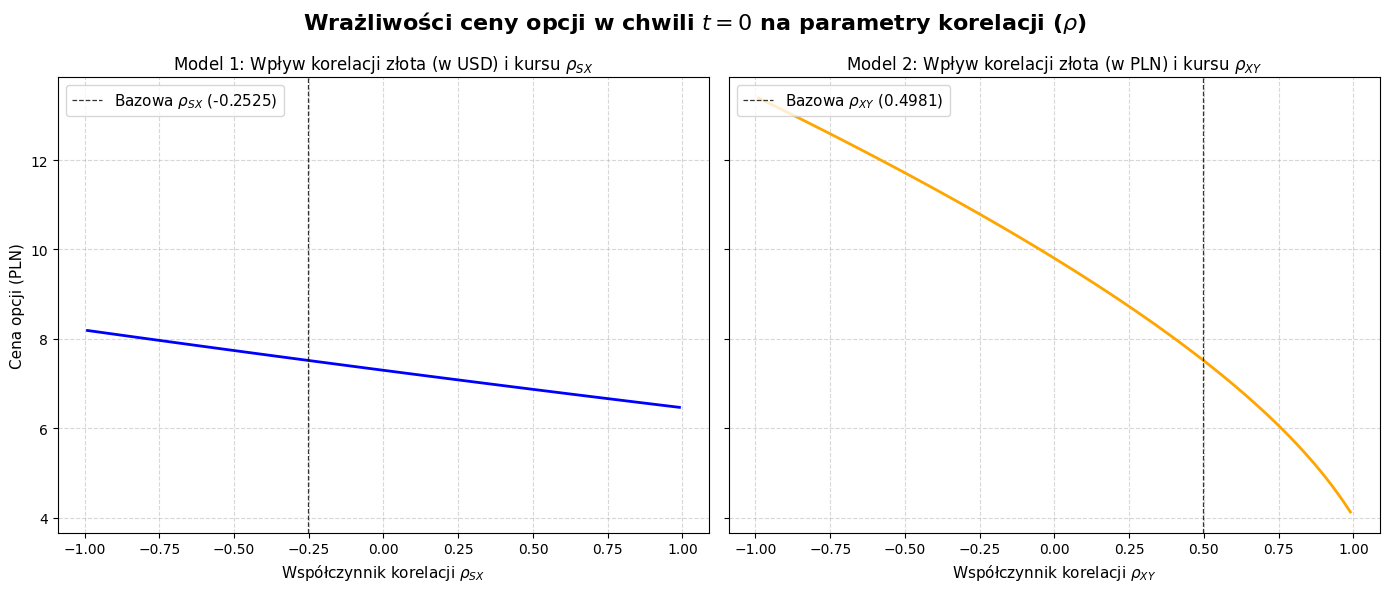

In [27]:
rho_values = np.linspace(-0.99, 0.99, 100)

prices_rho1 = [] # dla pierwszej kropki
prices_rho2 = [] # dla drugiej kropki

for rho in rho_values:
    p1 = price1(K, r_PLN, r_USD, rho, sigma_X, sigma_S)
    prices_rho1.append(p1)

    p2 = price2(K, r_PLN, r_USD, sigma_Y, sigma_X, rho)
    prices_rho2.append(p2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- lewy wykres - kropka 1: ---
ax1.plot(rho_values, prices_rho1, color='blue', linewidth=2)
ax1.axvline(x=rho_SX, color='black', linestyle='--', alpha=0.8, linewidth=0.9,
            label=f'Bazowa $\\rho_{{SX}}$ ({rho_SX:.4f})')

ax1.set_title('Model 1: Wpływ korelacji złota (w USD) i kursu $\\rho_{SX}$', fontsize=12)
ax1.set_xlabel('Współczynnik korelacji $\\rho_{SX}$', fontsize=11)
ax1.set_ylabel('Cena opcji (PLN)', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left', fontsize=11)

# --- prawy wykres - kropka 2: ---
ax2.plot(rho_values, prices_rho2, color='orange', linewidth=2)
ax2.axvline(x=rho_XY, color='black', linestyle='--', alpha=0.8, linewidth=0.9,
            label=f'Bazowa $\\rho_{{XY}}$ ({rho_XY:.4f})')

ax2.set_title('Model 2: Wpływ korelacji złota (w PLN) i kursu $\\rho_{XY}$', fontsize=12)
ax2.set_xlabel('Współczynnik korelacji $\\rho_{XY}$', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper left', fontsize=11)

plt.suptitle('Wrażliwości ceny opcji w chwili $t=0$ na parametry korelacji ($\\rho$)',
             fontsize=16, fontweight='bold')

plt.tight_layout()
#plt.savefig('plots/wrazliwosc_rho.png')
plt.show()

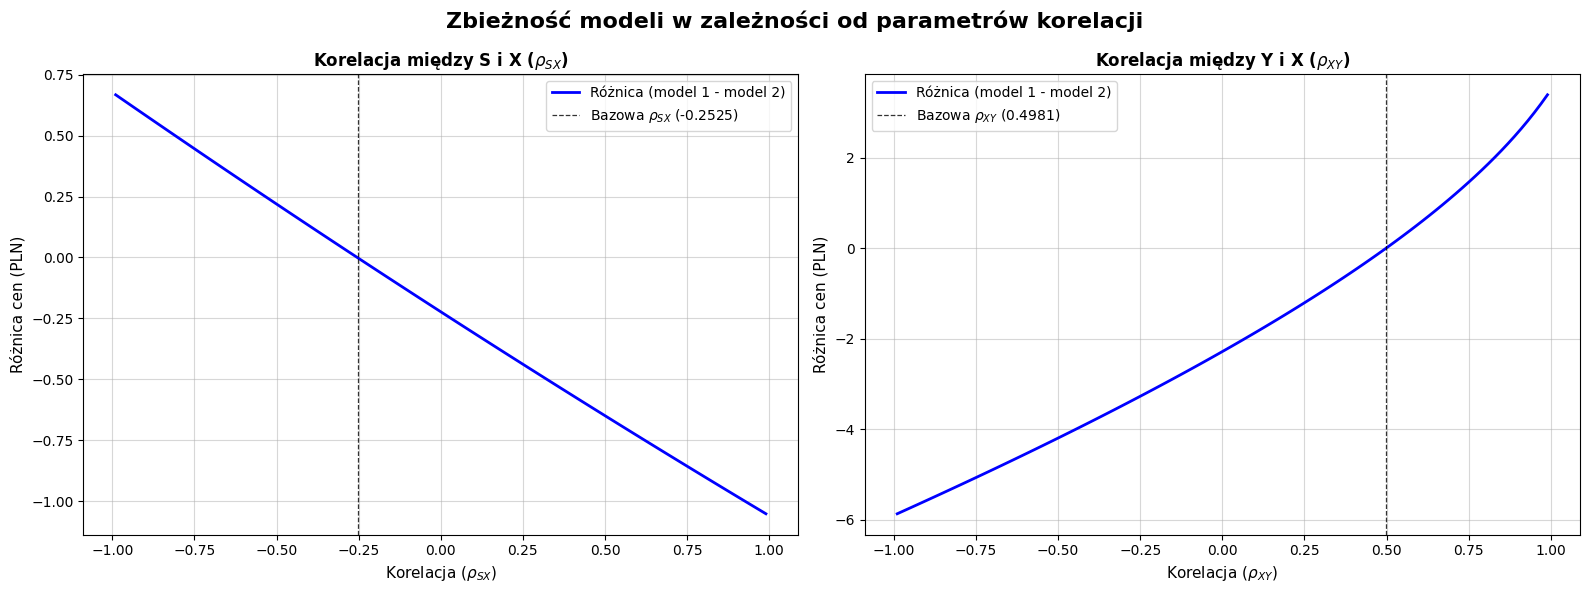

In [28]:
# Dane do pierwszego wykresu (zmienny rho_SX)
rho_sx_range = np.linspace(-0.99, 0.99, 100)
diffs_rho_sx = []
for rho_sx in rho_sx_range:
    p1 = price1(K, r_PLN, r_USD, rho_sx, sigma_X, sigma_S)
    p2 = price2(K, r_PLN, r_USD, sigma_Y, sigma_X, rho_XY)
    diffs_rho_sx.append(p1 - p2)

# Dane do drugiego wykresu (zmienny rho_YX / rho_XY)
rho_yx_range = np.linspace(-0.99, 0.99, 100)
diffs_rho_yx = []
for rho_yx in rho_yx_range:
    p1 = price1(K, r_PLN, r_USD, rho_SX, sigma_X, sigma_S)
    p2 = price2(K, r_PLN, r_USD, sigma_Y, sigma_X, rho_yx)
    diffs_rho_yx.append(p1 - p2)

# ==========================================
# 2. RYSOWANIE WYKRESÓW OBOK SIEBIE
# ==========================================
# Tworzymy jedną figurę z dwoma podwykresami (1 wiersz, 2 kolumny)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- LEWY WYKRES (rho_SX) ---
ax1.plot(rho_sx_range, diffs_rho_sx, label='Różnica (model 1 - model 2)', color='blue', linewidth=2)
ax1.axvline(x=rho_SX, color='black', linestyle='--', alpha=0.8, linewidth=0.9, label=f'Bazowa $\\rho_{{SX}}$ ({rho_SX:.4f})')
ax1.set_title('Korelacja między S i X ($\\rho_{SX}$)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Korelacja ($\\rho_{SX}$)', fontsize=11)
ax1.set_ylabel('Różnica cen (PLN)', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.5)

# --- PRAWY WYKRES (rho_XY) ---
ax2.plot(rho_yx_range, diffs_rho_yx, label='Różnica (model 1 - model 2)', color='blue', linewidth=2)
ax2.axvline(x=rho_XY, color='black', linestyle='--', alpha=0.8, linewidth=0.9, label=f'Bazowa $\\rho_{{XY}}$ ({rho_XY:.4f})')
ax2.set_title('Korelacja między Y i X ($\\rho_{XY}$)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Korelacja ($\\rho_{XY}$)', fontsize=11)
ax2.set_ylabel('Różnica cen (PLN)', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.5)
plt.suptitle("Zbieżność modeli w zależności od parametrów korelacji", fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()

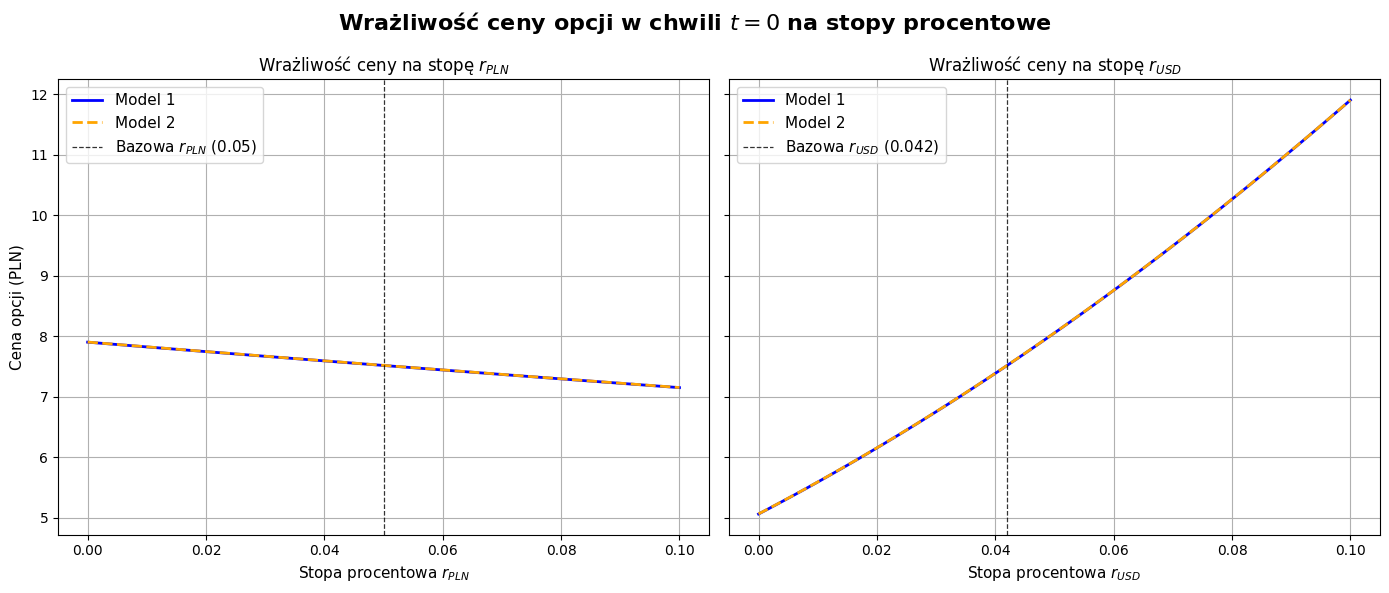

In [29]:
r_values = np.linspace(0, 0.1, 100)

prices_r_pln_1 = [price1(K, r, r_USD, rho_SX, sigma_X, sigma_S) for r in r_values]
prices_r_pln_2 = [price2(K, r, r_USD, sigma_Y, sigma_X, rho_XY) for r in r_values]
prices_r_usd_1 = [price1(K, r_PLN, r, rho_SX, sigma_X, sigma_S) for r in r_values]
prices_r_usd_2 = [price2(K, r_PLN, r, sigma_Y, sigma_X, rho_XY) for r in r_values]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# wykres - wrażliwość na sigma_Y
ax1.plot(r_values, prices_r_pln_1, color='blue', linewidth=2, label='Model 1')
ax1.plot(r_values, prices_r_pln_2, color='orange', linewidth=2, linestyle='--', label='Model 2')
ax1.axvline(x=r_PLN, color='black', linestyle='--', alpha=0.8, linewidth=0.9,
            label=f'Bazowa $r_{{PLN}}$ ({r_PLN})')
ax1.set_title('Wrażliwość ceny na stopę $r_{PLN}$', fontsize=12)
ax1.set_xlabel('Stopa procentowa $r_{PLN}$', fontsize=11)
ax1.set_ylabel('Cena opcji (PLN)', fontsize=11)
ax1.grid(True)
ax1.legend(loc='upper left', fontsize=11)

# wykres - wrażliwość na sigma_X
ax2.plot(r_values, prices_r_usd_1, color='blue', linewidth=2, label='Model 1')
ax2.plot(r_values, prices_r_usd_2, color='orange', linewidth=2, linestyle='--', label='Model 2')
ax2.axvline(x=r_USD, color='black', linestyle='--', alpha=0.8, linewidth=0.9,
            label=f'Bazowa $r_{{USD}}$ ({r_USD})')
ax2.set_title('Wrażliwość ceny na stopę $r_{USD}$', fontsize=12)
ax2.set_xlabel('Stopa procentowa $r_{USD}$', fontsize=11)
ax2.grid(True)
ax2.legend(loc='upper left', fontsize=11)

plt.suptitle('Wrażliwość ceny opcji w chwili $t=0$ na stopy procentowe',
             fontsize=16, fontweight='bold')
plt.tight_layout()
#plt.savefig('plots/wrazliwosc_stopy_procentowe.png')
plt.show()

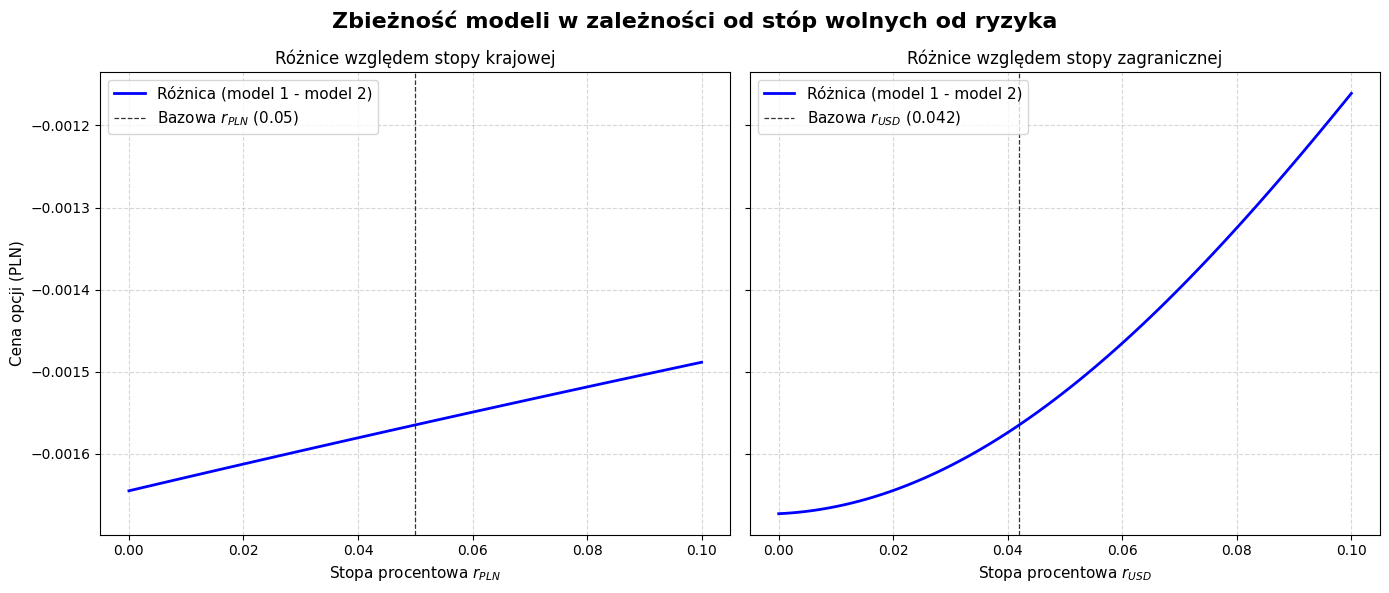

In [30]:
r_range = np.linspace(0, 0.1, 100)
diffs_r_pln = []
diffs_r_usd = []
for r in r_range:
    p1_pln = price1(K, r, r_USD, rho_SX, sigma_X, sigma_S)
    p2_pln = price2(K, r, r_USD, sigma_Y, sigma_X, rho_XY)
    diffs_r_pln.append(p1_pln - p2_pln)

    p1_usd = price1(K, r_PLN, r, rho_SX, sigma_X, sigma_S)
    p2_usd = price2(K, r_PLN, r, sigma_Y, sigma_X, rho_XY)
    diffs_r_usd.append(p1_usd - p2_usd)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- lewy wykres - stopa krajowa ---
ax1.plot(r_range, diffs_r_pln, color='blue', linewidth=2, label='Różnica (model 1 - model 2)')
ax1.axvline(x=r_PLN, color='black', linestyle='--', alpha=0.8, linewidth=0.9,
            label=f'Bazowa $r_{{PLN}}$ ({r_PLN})')

ax1.set_title('Różnice względem stopy krajowej', fontsize=12)
ax1.set_xlabel('Stopa procentowa $r_{PLN}$', fontsize=11)
ax1.set_ylabel('Cena opcji (PLN)', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left', fontsize=11)

# --- prawy wykres - kropka 2: ---
ax2.plot(r_range, diffs_r_usd, color='blue', linewidth=2, label='Różnica (model 1 - model 2)')
ax2.axvline(x=r_USD, color='black', linestyle='--', alpha=0.8, linewidth=0.9,
            label=f'Bazowa $r_{{USD}}$ ({r_USD})')

ax2.set_title('Różnice względem stopy zagranicznej', fontsize=12)
ax2.set_xlabel('Stopa procentowa $r_{USD}$', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper left', fontsize=11)

plt.suptitle('Zbieżność modeli w zależności od stóp wolnych od ryzyka',
             fontsize=16, fontweight='bold')

plt.tight_layout()
#plt.savefig('plots/zbieznosc_stopy_procentowe.png')
plt.show()